# Pipeline de Forecasting M5 — Méthodologie A1 CORRIGÉE (Anti-Leakage Strict)

Ce notebook reproduit fidèlement la méthodologie de la **solution gagnante de la compétition M5**
([Code of Winning Methods/A1](https://github.com/Mcompetitions/M5-methods)), adaptée à notre cas
d'usage Devoteam (vendeur = magasin `CA_1`, tous les produits).

## Points clés anti-leakage (stricts, conformes à la solution gagnante)

1. **`SHIFT_DAY = 28`** — tous les lags commencent à 28 jours minimum, jamais en dessous, car
   l'horizon de prédiction est de 28 jours : on ne peut connaître aucune vente plus récente que
   28 jours avant la date à prédire.
2. **Rolling means/std calculées sur les lags, jamais sur la cible brute** —
   toujours `shift(SHIFT_DAY).rolling(fenêtre).mean()`, jamais `rolling().mean()` seul.
3. **Price momentum** — ratio de prix par rapport à la semaine précédente (`shift(1)` sur les
   prix hebdomadaires, qui ne pose pas de problème de leakage car le prix de la semaine est
   toujours connu au moment de la vente).
4. **Validation multi-fold temporelle** — 3 folds successifs, jamais de mélange aléatoire des
   dates, pour s'assurer que le modèle n'apprend jamais sur des données futures par rapport à
   ce qu'il doit prédire.
5. **Release week filtering** — suppression des lignes antérieures à la sortie réelle du produit
   (les zéros avant le lancement ne sont pas de vraies ventes nulles).

## Périmètre

**Tous les produits du magasin `CA_1`** (~3049 produits).

**Corrections anti-leakage appliquées :**
1. `price_max/min/std/mean` calculés sur historique seul (wk ≤ 11608)
2. `price_momentum_m/y` supprimés (moyenne mois/année incluait le futur)
3. `rolling_mean_tmp` shift(1/7/14) supprimés — remplacés par shift(35/42)
4. 2 folds uniquement — d_1914-1941 jamais vus
5. `fillna(0)` au lieu de `dropna` — aucun produit exclu
6. `num_rounds` fixé par médiane CV sans regarder 1914-1941 Modèle : **LightGBM** (configuré GPU avec repli automatique CPU si GPU indisponible).

## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import os, gc, time, warnings, psutil
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

np.random.seed(42)

print("Imports OK")
print("LightGBM :", lgb.__version__)

Imports OK
LightGBM : 4.7.0


In [2]:
def get_memory_usage():
    return np.round(psutil.Process(os.getpid()).memory_info()[0] / 2.**30, 2)

def reduce_mem_usage(df, verbose=True):
    """
    Reduit l'empreinte memoire d'un DataFrame en choisissant le plus petit
    type numerique suffisant pour chaque colonne (technique de la solution A1).
    """
    numerics = ["int16", "int32", "int64", "float16", "float32", "float64"]
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"  Memoire : {start_mem:.1f}Mo -> {end_mem:.1f}Mo ({100*(start_mem-end_mem)/start_mem:.1f}% reduit)")
    return df

print("Fonctions utilitaires definies. RAM utilisee:", get_memory_usage(), "Go")

Fonctions utilitaires definies. RAM utilisee: 0.19 Go


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
TRAIN_DIR = r"C:\Users\ayady\Downloads\train"
TEST_DIR  = r"C:\Users\ayady\Downloads\test"

PATH_HIST_SALES   = os.path.join(TRAIN_DIR, "historique_sales_CA1.csv")
PATH_MOIS_SALES   = os.path.join(TEST_DIR,  "sales_du_mois_CA1.csv")
PATH_VERITE       = os.path.join(TEST_DIR,  "verite_terrain_CA1.csv")
PATH_HIST_PRICES  = os.path.join(TRAIN_DIR, "historique_prices_CA1.csv")
PATH_FUTUR_PRICES = os.path.join(TEST_DIR,  "prices_du_mois_CA1.csv")
PATH_CALENDAR     = os.path.join(TRAIN_DIR, "calendar.csv")

OUTPUT_DIR = r"C:\Users\ayady\Downloads\prediction"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET    = "sales"
SHIFT_DAY = 28   # horizon de prédiction = 28 jours (M5 standard)

# ── Paramètres extraits AUTOMATIQUEMENT depuis les fichiers ───────────────
print("Extraction automatique des paramètres depuis les fichiers...")

# 1. STORE_ID_CLIENT : extrait depuis historique_sales
_hist_meta = pd.read_csv(PATH_HIST_SALES, usecols=["store_id"], nrows=1)
STORE_ID_CLIENT = _hist_meta["store_id"].iloc[0]

# 2. Colonnes jours → frontières temporelles
_hist_cols   = pd.read_csv(PATH_HIST_SALES,   nrows=0).columns.tolist()
_mois_cols   = pd.read_csv(PATH_MOIS_SALES,   nrows=0).columns.tolist()
_verite_cols = pd.read_csv(PATH_VERITE,       nrows=0).columns.tolist()

_hist_days   = sorted([c for c in _hist_cols   if c.startswith("d_")],
                       key=lambda x: int(x[2:]))
_mois_days   = sorted([c for c in _mois_cols   if c.startswith("d_")],
                       key=lambda x: int(x[2:]))
_verite_days = sorted([c for c in _verite_cols if c.startswith("d_")],
                       key=lambda x: int(x[2:]))

# Frontières temporelles
HIST_START = int(_hist_days[0][2:])     # premier jour historique (= 1)
TRAIN_END  = int(_hist_days[-1][2:])    # dernier jour historique (= 1885)
MOIS_START = int(_mois_days[0][2:])     # premier jour mois (= 1886)
MOIS_END   = int(_mois_days[-1][2:])    # dernier jour mois (= 1913)
PRED_START = int(_verite_days[0][2:])   # premier jour prédiction (= 1914)
PRED_END   = int(_verite_days[-1][2:])  # dernier jour prédiction (= 1941)

# Fold 1 = cut à TRAIN_END - 28 jours
FOLD_1_END   = TRAIN_END - SHIFT_DAY       # = 1885 - 28 = 1857
FOLD_1_START = FOLD_1_END + 1              # = 1858

# 3. WK_HIST_MAX : dernière semaine de l'historique prix
_hist_prices_wk = pd.read_csv(PATH_HIST_PRICES, usecols=["wm_yr_wk"])
WK_HIST_MAX = int(_hist_prices_wk["wm_yr_wk"].max())

# 4. WK_FUTUR_MIN : première semaine des prix futurs
_futur_prices_wk = pd.read_csv(PATH_FUTUR_PRICES, usecols=["wm_yr_wk"])
WK_FUTUR_MIN = int(_futur_prices_wk["wm_yr_wk"].min())

# 5. SUFFIX_ID : suffixe des identifiants produits
_sample_id = pd.read_csv(PATH_HIST_SALES, usecols=["id"], nrows=1)["id"].iloc[0]
# Format attendu : "FOODS_1_001_CA_1_evaluation"
# On extrait la partie après le item_id (= "_CA_1_evaluation" ou similaire)
_item_id = pd.read_csv(PATH_HIST_SALES, usecols=["item_id"], nrows=1)["item_id"].iloc[0]
SUFFIX_ID = _sample_id.replace(_item_id, "")   # = "_CA_1_evaluation"

del _hist_meta, _hist_cols, _mois_cols, _verite_cols
del _hist_days, _mois_days, _verite_days
del _hist_prices_wk, _futur_prices_wk, _sample_id, _item_id

# ── FOLDS construits depuis les paramètres extraits ───────────────────────
FOLDS = [
    {"train_end": FOLD_1_END,  "val_start": FOLD_1_START, "val_end": TRAIN_END},
    {"train_end": TRAIN_END,   "val_start": MOIS_START,   "val_end": MOIS_END},
]

# ── Affichage ─────────────────────────────────────────────────────────────
print(f"  STORE_ID_CLIENT : {STORE_ID_CLIENT}")
print(f"  SUFFIX_ID       : {SUFFIX_ID}")
print(f"  HIST_START      : d_{HIST_START}")
print(f"  TRAIN_END       : d_{TRAIN_END}   (fin historique)")
print(f"  MOIS_START      : d_{MOIS_START}")
print(f"  MOIS_END        : d_{MOIS_END}   (fin mois validation)")
print(f"  PRED_START      : d_{PRED_START}   (début prédiction finale)")
print(f"  PRED_END        : d_{PRED_END}   (fin prédiction finale)")
print(f"  FOLD_1_END      : d_{FOLD_1_END}")
print(f"  WK_HIST_MAX     : {WK_HIST_MAX}")
print(f"  WK_FUTUR_MIN    : {WK_FUTUR_MIN}")
print(f"  SHIFT_DAY       : {SHIFT_DAY}")
print()
for label, path in [
    ("hist_sales",   PATH_HIST_SALES),
    ("mois_sales",   PATH_MOIS_SALES),
    ("verite",       PATH_VERITE),
    ("hist_prices",  PATH_HIST_PRICES),
    ("futur_prices", PATH_FUTUR_PRICES),
    ("calendar",     PATH_CALENDAR),
]:
    ok = os.path.exists(path)
    print(f"  {'✓' if ok else '✗'} {label:<15}: {path}")


Extraction automatique des paramètres depuis les fichiers...
  STORE_ID_CLIENT : CA_1
  SUFFIX_ID       : _CA_1_evaluation
  HIST_START      : d_1
  TRAIN_END       : d_1885   (fin historique)
  MOIS_START      : d_1886
  MOIS_END        : d_1913   (fin mois validation)
  PRED_START      : d_1914   (début prédiction finale)
  PRED_END        : d_1941   (fin prédiction finale)
  FOLD_1_END      : d_1857
  WK_HIST_MAX     : 11613
  WK_FUTUR_MIN    : 11613
  SHIFT_DAY       : 28

  ✓ hist_sales     : C:\Users\ayady\Downloads\train\historique_sales_CA1.csv
  ✓ mois_sales     : C:\Users\ayady\Downloads\test\sales_du_mois_CA1.csv
  ✓ verite         : C:\Users\ayady\Downloads\test\verite_terrain_CA1.csv
  ✓ hist_prices    : C:\Users\ayady\Downloads\train\historique_prices_CA1.csv
  ✓ futur_prices   : C:\Users\ayady\Downloads\test\prices_du_mois_CA1.csv
  ✓ calendar       : C:\Users\ayady\Downloads\train\calendar.csv


## 1. Chargement et transformation en grille (wide → long)

On charge `sales_train_evaluation.csv` pour **tous les produits de CA_1**, puis on transforme
en format long via `melt` — exactement la même technique que la solution gagnante.

In [4]:
print("Chargement et reconstitution de train_df et prices_df ...")
t0 = time.time()

# ── train_df : wide d_1 → d_1913 (identique à sales_train_evaluation filtré CA_1) ──
hist_sales = pd.read_csv(PATH_HIST_SALES)
mois_sales = pd.read_csv(PATH_MOIS_SALES)
train_df = hist_sales.merge(
    mois_sales.drop(columns=["dept_id","cat_id","store_id","state_id"], errors="ignore"),
    on=["id","item_id"], how="left"
)
del hist_sales, mois_sales
gc.collect()

# ── prices_df : toutes semaines CA_1 (identique à sell_prices filtré CA_1) ──
# IMPORTANT : prices_df est conservé en mémoire jusqu'à la fin (pas de del)
hist_prices  = pd.read_csv(PATH_HIST_PRICES)
futur_prices = pd.read_csv(PATH_FUTUR_PRICES)
prices_df = pd.concat([hist_prices, futur_prices], ignore_index=True)
del hist_prices, futur_prices
gc.collect()

# ── Calendrier ──────────────────────────────────────────────────────────────
calendar_df = pd.read_csv(PATH_CALENDAR)

# ── Vérité terrain (réservée pour comparaison finale uniquement) ──────────
verite_df = pd.read_csv(PATH_VERITE)

print(f"  train_df    : {train_df.shape}")
day_cols_check = [c for c in train_df.columns if c.startswith("d_")]
print(f"    Jours     : {day_cols_check[0]} → {day_cols_check[-1]} ({len(day_cols_check)} jours)")
print(f"    Produits  : {train_df['item_id'].nunique()}")
print(f"  prices_df   : {prices_df.shape}")
print(f"    wm_yr_wk  : {prices_df['wm_yr_wk'].min()} → {prices_df['wm_yr_wk'].max()}")
print(f"  calendar_df : {calendar_df.shape}")
print(f"  verite_df   : {verite_df.shape}  (d_1914→d_1941 — comparaison finale uniquement)")
print(f"  Temps total : {time.time()-t0:.1f}s")


Chargement et reconstitution de train_df et prices_df ...
  train_df    : (3049, 1919)
    Jours     : d_1 → d_1913 (1913 jours)
    Produits  : 3049
  prices_df   : (689265, 4)
    wm_yr_wk  : 11101 → 11617
  calendar_df : (1969, 14)
  verite_df   : (3049, 34)  (d_1914→d_1941 — comparaison finale uniquement)
  Temps total : 0.7s


In [5]:
# Vérification CA_1 (NB0 a déjà filtré)
assert train_df["store_id"].nunique() == 1
assert train_df["store_id"].iloc[0] == STORE_ID_CLIENT
assert prices_df["store_id"].nunique() == 1
print(f"✓ train_df  : {STORE_ID_CLIENT} | {train_df.shape[0]} produits")
print(f"✓ prices_df : {STORE_ID_CLIENT} | {prices_df.shape[0]} lignes")
print("RAM utilisee:", get_memory_usage(), "Go")


✓ train_df  : CA_1 | 3049 produits
✓ prices_df : CA_1 | 689265 lignes
RAM utilisee: 0.27 Go


In [6]:
# ── Creer la grille (melt wide -> long) ──
index_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

grid_df = pd.melt(
    train_df,
    id_vars=index_columns,
    var_name="d",
    value_name=TARGET
)

print(f"Grille creee : {grid_df.shape}")
print("RAM utilisee:", get_memory_usage(), "Go")


gc.collect()

Grille creee : (5832737, 8)
RAM utilisee: 0.62 Go


0

In [7]:
# ── Filtrer les zeros avant la sortie reelle du produit (release week) ──
# Methode A1 : les zeros avant le premier prix connu ne sont pas de vraies ventes nulles
release_df = prices_df.groupby(["store_id", "item_id"])["wm_yr_wk"].agg(["min"]).reset_index()
release_df.columns = ["store_id", "item_id", "release"]

grid_df = grid_df.merge(release_df, on=["store_id", "item_id"], how="left")
grid_df = grid_df.merge(calendar_df[["wm_yr_wk", "d"]], on=["d"], how="left")

avant = len(grid_df)
grid_df = grid_df[grid_df["wm_yr_wk"] >= grid_df["release"]].reset_index(drop=True)
print(f"Lignes avant filtrage release : {avant}")
print(f"Lignes apres filtrage release : {len(grid_df)} ({100*(avant-len(grid_df))/avant:.1f}% supprimees)")

del release_df
gc.collect()

Lignes avant filtrage release : 5832737
Lignes apres filtrage release : 4702895 (19.4% supprimees)


0

In [8]:
grid_df = reduce_mem_usage(grid_df)
prices_df = reduce_mem_usage(prices_df)

  Memoire : 358.8Mo -> 278.1Mo (22.5% reduit)
  Memoire : 21.0Mo -> 13.1Mo (37.5% reduit)


## 2. Features de prix (price momentum, conforme méthode A1)

On calcule les agrégations de prix par produit/magasin, puis le **price momentum** —
le ratio entre le prix actuel et le prix de la semaine précédente, le mois, et l'année.
Ce calcul est basé sur `shift(1)` au niveau **hebdomadaire** (le prix M5 est fixé par semaine),
ce qui ne crée aucun leakage car le prix de la semaine en cours est toujours connu.

In [9]:
# ── Features de prix -- ANTI-LEAKAGE STRICT ──────────────────────────────
# CORRECTION : price_max/min/std/mean/nunique calculés UNIQUEMENT sur les
# semaines historiques (wm_yr_wk <= 11608, soit jusqu'à d_1885).
# Les semaines 11609+ couvrent d_1886-d_1941 -- les inclure crée un leakage
# car les prix futurs contaminent les statistiques de toutes les lignes passées.
#
# price_momentum_m et price_momentum_y SUPPRIMÉS : ils divisent par la moyenne
# du mois/année entier, incluant des semaines futures de la même période.
# Seul price_momentum (shift(1) semaine précédente) est conservé -- il est
# toujours connu au moment de la vente et ne crée aucun leakage.

# WK_HIST_MAX extrait automatiquement en Cell 4 depuis historique_prices_CA1.csv

# Calculer les stats uniquement sur l'historique pur
prices_hist = prices_df[prices_df["wm_yr_wk"] <= WK_HIST_MAX].copy()
price_stats = prices_hist.groupby(["store_id", "item_id"])["sell_price"].agg(
    price_max    = "max",
    price_min    = "min",
    price_std    = "std",
    price_mean   = "mean",
    price_nunique= "nunique"
).reset_index()
del prices_hist

# Merger les stats historiques sur TOUTE la table des prix (y compris semaines futures)
# Les stats elles-mêmes ne contiennent pas de données futures
prices_df = prices_df.merge(price_stats, on=["store_id", "item_id"], how="left")
del price_stats

# price_norm = prix courant / max historique (pas de leakage : max calculé sur passé)
prices_df["price_norm"] = prices_df["sell_price"] / prices_df["price_max"]

# Price momentum semaine : ratio prix semaine courante / semaine précédente
# Pas de leakage car le prix de la semaine est toujours connu avant les ventes
prices_df["price_momentum"] = prices_df["sell_price"] / prices_df.groupby(
    ["store_id", "item_id"])["sell_price"].transform(lambda x: x.shift(1))

# price_momentum_m et price_momentum_y SUPPRIMÉS (leakage confirmé)

gc.collect()
print("Features de prix créées (anti-leakage) :", prices_df.shape)
print("Colonnes prix :", [c for c in prices_df.columns if "price" in c])
prices_df = reduce_mem_usage(prices_df)


Features de prix créées (anti-leakage) : (689265, 11)
Colonnes prix : ['sell_price', 'price_max', 'price_min', 'price_std', 'price_mean', 'price_nunique', 'price_norm', 'price_momentum']
  Memoire : 31.6Mo -> 21.7Mo (31.2% reduit)


In [10]:
# ── Fusionner les prix dans la grille ──
original_columns = list(grid_df)
grid_df = grid_df.merge(prices_df, on=["store_id","item_id","wm_yr_wk"], how="left")
keep_columns = [c for c in list(grid_df) if c not in original_columns]
print("Nouvelles colonnes de prix ajoutees :", keep_columns)

gc.collect()
grid_df = reduce_mem_usage(grid_df)
print("Shape apres fusion prix :", grid_df.shape)
print("RAM utilisee:", get_memory_usage(), "Go")

Nouvelles colonnes de prix ajoutees : ['sell_price', 'price_max', 'price_min', 'price_std', 'price_mean', 'price_nunique', 'price_norm', 'price_momentum']
  Memoire : 345.8Mo -> 345.8Mo (0.0% reduit)
Shape apres fusion prix : (4708993, 18)
RAM utilisee: 0.61 Go


## 3. Features calendaires

In [11]:
calendar_cols = ["d","date","wday","month","year","event_name_1","event_type_1",
                  "event_name_2","event_type_2","snap_CA"]

grid_df = grid_df.merge(calendar_df[calendar_cols], on=["d"], how="left")

# Encoder les variables categorielles event_* en entiers (NaN -> -1)
for col in ["event_name_1","event_type_1","event_name_2","event_type_2"]:
    grid_df[col] = grid_df[col].astype("category").cat.codes.astype(np.int16)

grid_df["date"] = pd.to_datetime(grid_df["date"])
grid_df["jour_semaine"] = grid_df["date"].dt.dayofweek
grid_df["jour_du_mois"] = grid_df["date"].dt.day

grid_df = reduce_mem_usage(grid_df)
print("Shape apres features calendaires :", grid_df.shape)
print("RAM utilisee:", get_memory_usage(), "Go")

  Memoire : 597.3Mo -> 431.1Mo (27.8% reduit)
Shape apres features calendaires : (4708993, 29)
RAM utilisee: 0.69 Go


## 4. Lags et Rolling Features — méthode anti-leakage stricte (A1)

**Règle d'or anti-leakage :** tous les lags commencent à `SHIFT_DAY = 28` (jamais en dessous),
et toutes les moyennes/écarts-types glissants sont calculés **sur les valeurs déjà décalées**
(`shift(SHIFT_DAY).rolling(fenêtre)`), jamais directement sur la cible brute.

Pourquoi 28 et pas moins ? Parce que pour prédire le jour `J`, on doit utiliser un modèle qui
sera appliqué de la même façon pour prédire **les 28 jours du mois suivant** sans connaître
les ventes entre J et J+27. Utiliser un lag de 7 jours serait utilisable pour le jour J+1 mais
plus pour le jour J+28 — la solution gagnante résout ça en n'utilisant **que des lags ≥ 28**,
qui restent valides peu importe quel jour de l'horizon de 28 jours on prédit.

In [12]:
grid_df_lags = grid_df[["id","d",TARGET]].copy()

# ── Lags : de 28 a 42 jours (15 lags), jamais en dessous de SHIFT_DAY ──
print("Creation des lags (28 a 42 jours)...")
t0 = time.time()

LAG_DAYS = [col for col in range(SHIFT_DAY, SHIFT_DAY + 15)]
grid_df_lags = grid_df_lags.assign(**{
    f"{TARGET}_lag_{l}": grid_df_lags.groupby(["id"])[TARGET].transform(lambda x: x.shift(l))
    for l in LAG_DAYS
})

for col in grid_df_lags.columns:
    if "lag" in col:
        grid_df_lags[col] = grid_df_lags[col].astype(np.float16)

print(f"  Lags crees en {(time.time()-t0)/60:.2f} min")

Creation des lags (28 a 42 jours)...
  Lags crees en 0.38 min


In [13]:
# ── Rolling means/std : shift(SHIFT_DAY) PUIS rolling -- jamais l ordre inverse ──
print("Creation des rolling means/std...")
t0 = time.time()

for window in [7, 14, 30, 60, 180]:
    grid_df_lags[f"rolling_mean_{window}"] = grid_df_lags.groupby(["id"])[TARGET].transform(
        lambda x: x.shift(SHIFT_DAY).rolling(window).mean()
    ).astype(np.float16)
    grid_df_lags[f"rolling_std_{window}"] = grid_df_lags.groupby(["id"])[TARGET].transform(
        lambda x: x.shift(SHIFT_DAY).rolling(window).std()
    ).astype(np.float16)
    print(f"  Rolling {window}j termine")

print(f"  Rollings crees en {(time.time()-t0)/60:.2f} min")

Creation des rolling means/std...
  Rolling 7j termine
  Rolling 14j termine
  Rolling 30j termine
  Rolling 60j termine
  Rolling 180j termine
  Rollings crees en 0.31 min


In [14]:
# ── Rolling means avec shift ≥ 28 UNIQUEMENT -- anti-leakage strict ────────
# CORRECTION : les rolling_mean_tmp avec shift(1), shift(7), shift(14) sont
# SUPPRIMÉS. Ils utilisent des ventes de J-1, J-7, J-14 pour prédire J --
# valides seulement pour d_1914 (1er jour), mais IMPOSSIBLES pour d_1915 à
# d_1941 car ces ventes intermédiaires n'existent pas encore en production.
# On les remplace par des rolling avec shift 35 et 42 (toujours ≥ 28 = horizon).
print("Création des rolling courts avec shift ≥ 28 (anti-leakage)...")
t0 = time.time()

for d_shift in [35, 42]:          # jamais < 28 = SHIFT_DAY
    for d_window in [7, 14, 30, 60]:
        col_name = f"rolling_mean_ext_{d_shift}_{d_window}"
        grid_df_lags[col_name] = grid_df_lags.groupby(["id"])[TARGET].transform(
            lambda x: x.shift(d_shift).rolling(d_window).mean()
        ).astype(np.float16)

print(f"  Terminé en {(time.time()-t0)/60:.2f} min")
print("Shape grid_df_lags :", grid_df_lags.shape)
print("RAM utilisée:", get_memory_usage(), "Go")


Création des rolling courts avec shift ≥ 28 (anti-leakage)...
  Terminé en 0.24 min
Shape grid_df_lags : (4708993, 36)
RAM utilisée: 1.07 Go


In [15]:
# ── Fusionner les lags dans la grille principale ──
grid_df = grid_df.merge(grid_df_lags.drop(columns=[TARGET]), on=["id","d"], how="left")

del grid_df_lags
gc.collect()
grid_df = reduce_mem_usage(grid_df)
print("Shape final apres tous les features :", grid_df.shape)
print("RAM utilisee:", get_memory_usage(), "Go")

  Memoire : 729.4Mo -> 729.4Mo (0.0% reduit)
Shape final apres tous les features : (4721189, 62)
RAM utilisee: 0.99 Go


## 5. Préparation finale avant entraînement

On convertit `d` en entier, on définit les colonnes features (tout sauf les identifiants et la
cible), et on encode les variables catégorielles pour LightGBM.

In [16]:
grid_df["d"] = grid_df["d"].apply(lambda x: int(x[2:]))

# cat_features complet (utilise pour CPU, sans contrainte de bins)
cat_features_full = ["item_id","dept_id","cat_id","store_id","state_id",
                       "event_name_1","event_type_1","event_name_2","event_type_2"]

# cat_features_gpu : item_id retire -- a ~3049 valeurs distinctes, il depasse la limite
# de 256 bins imposee par LightGBM sur GPU/CUDA pour les features categorielles.
# item_id reste neanmoins present comme feature NUMERIQUE encodee (deja convertie en
# int16 ci-dessous) -- LightGBM peut tres bien exploiter cette information meme sans
# le flag categorical_feature, simplement en la traitant comme une valeur ordonnee.
cat_features_gpu = ["dept_id","cat_id","store_id","state_id",
                      "event_name_1","event_type_1","event_name_2","event_type_2"]

for col in ["item_id","dept_id","cat_id","store_id","state_id"]:
    grid_df[col] = grid_df[col].astype("category").cat.codes.astype(np.int16)

useless_cols = ["id","d","date",TARGET,"wm_yr_wk","release"]
FEATURES = [c for c in grid_df.columns if c not in useless_cols]

print(f"Nombre de features : {len(FEATURES)}")
print(FEATURES)

Nombre de features : 56
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'sell_price', 'price_max', 'price_min', 'price_std', 'price_mean', 'price_nunique', 'price_norm', 'price_momentum', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'jour_semaine', 'jour_du_mois', 'sales_lag_28', 'sales_lag_29', 'sales_lag_30', 'sales_lag_31', 'sales_lag_32', 'sales_lag_33', 'sales_lag_34', 'sales_lag_35', 'sales_lag_36', 'sales_lag_37', 'sales_lag_38', 'sales_lag_39', 'sales_lag_40', 'sales_lag_41', 'sales_lag_42', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_mean_60', 'rolling_std_60', 'rolling_mean_180', 'rolling_std_180', 'rolling_mean_ext_35_7', 'rolling_mean_ext_35_14', 'rolling_mean_ext_35_30', 'rolling_mean_ext_35_60', 'rolling_mean_ext_42_7', 'rolling_mean_ext_42_14', 'rolling_mean_ext_42_30', 'rolling_mean_ext_42_60']


## 6. Validation multi-fold temporelle (anti-leakage strict)

On reproduit la stratégie de validation de la solution gagnante : **3 folds successifs**,
chacun entraîné uniquement sur le passé du point de coupure, et évalué sur les 28 jours
qui suivent immédiatement — jamais de mélange aléatoire des dates.

| Fold | Train (jours) | Validation (jours) |
|---|---|---|
| 1 | 1 → 1857 | 1858 → 1885 |
| 2 | 1 → 1885 | 1886 → 1913 |
| 3 | 1 → 1913 | 1914 → 1941 |

Chaque fold est strictement postérieur au précédent — aucune donnée du futur n'est jamais
utilisée pour entraîner un modèle qui prédit le passé d'un autre fold.

In [17]:
# ── 2 folds de validation temporelle stricte ────────────────────────────────
# Paramètres extraits automatiquement en Cell 4 depuis les fichiers.
# Fold 1 : train d_{HIST_START}-{FOLD_1_END}  | val d_{FOLD_1_START}-{TRAIN_END}
# Fold 2 : train d_{HIST_START}-{TRAIN_END}   | val d_{MOIS_START}-{MOIS_END}
# Période de prédiction finale (jamais vue) : d_{PRED_START}-{PRED_END}

# FOLDS déjà construit en Cell 4
for i, f in enumerate(FOLDS, 1):
    print(f"Fold {i} : train d_1-{f['train_end']}  |  val d_{f['val_start']}-{f['val_end']}")
print(f"Période de prédiction finale (jamais vue) : d_{PRED_START} - d_{PRED_END}")


Fold 1 : train d_1-1857  |  val d_1858-1885
Fold 2 : train d_1-1885  |  val d_1886-1913
Période de prédiction finale (jamais vue) : d_1914 - d_1941


## 7. Entraînement LightGBM — Détection automatique du GPU NVIDIA (RTX 5060)

Sur un système avec plusieurs GPU (Intel intégré + NVIDIA dédié), `gpu_platform_id=0` ne
correspond pas forcément au GPU NVIDIA — l'ordre dépend du système et du driver installé
en premier. On utilise `pyopencl` pour **lister toutes les plateformes/devices OpenCL
disponibles**, identifier celui dont le nom contient `"NVIDIA"` ou `"RTX"`, et configurer
LightGBM avec les bons `gpu_platform_id`/`gpu_device_id` — sans deviner.

## 7. Entraînement LightGBM — GPU avec repli automatique CPU

On essaie d'abord `device="gpu"` (configuration demandée). Si l'environnement ne supporte pas
le GPU pour LightGBM (driver OpenCL/CUDA manquant), on bascule automatiquement sur CPU sans
interrompre l'exécution.

In [18]:
# ── Detection automatique de la plateforme/device NVIDIA via pyopencl ──
# Plutot que de deviner gpu_platform_id=0, on liste reellement les plateformes
# OpenCL disponibles et on cherche celle dont le nom contient "NVIDIA" -- on ne
# se fie jamais a un ID suppose, on l identifie a partir du nom reel du vendeur.

def detecter_platform_device_nvidia():
    try:
        import pyopencl as cl
    except ImportError:
        print("pyopencl non installe -- installation en cours...")
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "pyopencl", "--quiet"], check=False)
        try:
            import pyopencl as cl
        except ImportError:
            print("Impossible d installer pyopencl -- detection manuelle indisponible")
            return None, None

    try:
        platforms = cl.get_platforms()
        print("Plateformes OpenCL detectees :")
        for p_idx, platform in enumerate(platforms):
            print("  Platform", p_idx, ":", platform.name)
            devices = platform.get_devices()
            for d_idx, device in enumerate(devices):
                print("    Device", d_idx, ":", device.name)
                if "NVIDIA" in platform.name.upper() or "NVIDIA" in device.name.upper():
                    print("    --> NVIDIA detecte ici : gpu_platform_id=" + str(p_idx) +
                          ", gpu_device_id=" + str(d_idx))
                    return p_idx, d_idx
        print("Aucune plateforme/device NVIDIA trouve dans la liste OpenCL")
        return None, None
    except Exception as e:
        print("Erreur lors de la detection OpenCL :", str(e)[:150])
        return None, None

NVIDIA_PLATFORM_ID, NVIDIA_DEVICE_ID = detecter_platform_device_nvidia()

pyopencl non installe -- installation en cours...
Plateformes OpenCL detectees :
  Platform 0 : NVIDIA CUDA
    Device 0 : NVIDIA GeForce RTX 5060 Laptop GPU
    --> NVIDIA detecte ici : gpu_platform_id=0, gpu_device_id=0


In [19]:
# ── Configuration GPU : detection automatique de la plateforme NVIDIA (RTX 5060) ──
# IMPORTANT : gpu_platform_id=0 ne correspond PAS forcement au GPU NVIDIA.
# Sur la plupart des laptops Windows (Intel + NVIDIA), le driver OpenCL Intel
# s enregistre souvent en platform_id=0, et NVIDIA en platform_id=1 (ou l inverse
# selon le systeme). Il faut donc interroger pyopencl pour identifier precisement
# quelle plateforme/device contient "NVIDIA" dans son nom, plutot que de deviner.

LGB_PARAMS_BASE = {
    "boosting_type": "gbdt",
    "objective": "tweedie",
    "tweedie_variance_power": 1.1,
    "metric": "rmse",
    "subsample": 0.5,
    "subsample_freq": 1,
    "learning_rate": 0.03,
    "num_leaves": 2**8 - 1,
    "min_data_in_leaf": 2**8 - 1,
    "feature_fraction": 0.5,
    "boost_from_average": False,
    "verbose": -1,
    "max_bin": 255,
}

N_ESTIMATORS = 1400


def detecter_platform_device_nvidia():
    """
    Interroge OpenCL via pyopencl pour trouver le (platform_id, device_id)
    exact correspondant a un GPU NVIDIA. Retourne (platform_id, device_id)
    ou (None, None) si aucun GPU NVIDIA n est trouve via OpenCL.
    """
    try:
        import pyopencl as cl
    except ImportError:
        print("pyopencl non installe -- installation en cours...")
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "pyopencl",
                         "--quiet", "--break-system-packages"], check=False)
        try:
            import pyopencl as cl
        except ImportError:
            print("Impossible d installer pyopencl -- detection automatique indisponible")
            return None, None

    try:
        platforms = cl.get_platforms()
        for p_id, platform in enumerate(platforms):
            devices = platform.get_devices()
            for d_id, device in enumerate(devices):
                nom_device = device.name.upper()
                nom_platform = platform.name.upper()
                print("  Platform", p_id, "(" + platform.name + ") / Device", d_id,
                      "(" + device.name + ")")
                if "NVIDIA" in nom_device or "NVIDIA" in nom_platform or "RTX" in nom_device:
                    return p_id, d_id
    except Exception as e:
        print("Erreur lors de la detection OpenCL :", str(e)[:150])

    return None, None


def tester_device(params_test, label):
    try:
        X_test = np.random.rand(200, 5).astype(np.float32)
        y_test = np.random.rand(200).astype(np.float32)
        test_data = lgb.Dataset(X_test, label=y_test)
        p = dict(params_test)
        p["min_data_in_leaf"] = 5
        p["num_leaves"] = 7
        lgb.train(p, test_data, num_boost_round=3)
        print(label, ": disponible et fonctionnel")
        return True
    except Exception as e:
        print(label, ": indisponible (", str(e)[:100], ")")
        return False


def get_lgb_params():
    print("Recherche des plateformes/devices OpenCL disponibles...")
    nvidia_platform_id, nvidia_device_id = detecter_platform_device_nvidia()

    # 1. Si un device NVIDIA a ete identifie precisement via OpenCL, l utiliser en priorite
    if nvidia_platform_id is not None:
        params_gpu_nvidia = dict(LGB_PARAMS_BASE)
        params_gpu_nvidia["device"] = "gpu"
        params_gpu_nvidia["gpu_platform_id"] = nvidia_platform_id
        params_gpu_nvidia["gpu_device_id"] = nvidia_device_id
        label = "LightGBM device=gpu (NVIDIA detecte: platform=" + str(nvidia_platform_id) + \
                ", device=" + str(nvidia_device_id) + ")"
        if tester_device(params_gpu_nvidia, label):
            print("--> Utilisation du GPU NVIDIA detecte automatiquement")
            return params_gpu_nvidia

    # 2. Tenter CUDA (backend direct, cible nativement la carte NVIDIA si compile)
    params_cuda = dict(LGB_PARAMS_BASE)
    params_cuda["device"] = "cuda"
    if tester_device(params_cuda, "LightGBM device=cuda"):
        print("--> Utilisation de device=cuda")
        return params_cuda

    # 3. Repli CPU si rien d autre ne fonctionne
    params_cpu = dict(LGB_PARAMS_BASE)
    params_cpu["device"] = "cpu"
    print("--> Repli sur device=cpu (aucun GPU NVIDIA exploitable trouve)")
    return params_cpu


ACTIVE_PARAMS = get_lgb_params()
print()
print("Parametres LightGBM actifs :")
for k, v in ACTIVE_PARAMS.items():
    print(" ", k, ":", v)
print("  n_estimators (num_boost_round) :", N_ESTIMATORS)

Recherche des plateformes/devices OpenCL disponibles...
  Platform 0 (NVIDIA CUDA) / Device 0 (NVIDIA GeForce RTX 5060 Laptop GPU)
LightGBM device=gpu (NVIDIA detecte: platform=0, device=0) : indisponible ( GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1 )
LightGBM device=cuda : indisponible ( CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1 (NV )
--> Repli sur device=cpu (aucun GPU NVIDIA exploitable trouve)

Parametres LightGBM actifs :
  boosting_type : gbdt
  objective : tweedie
  tweedie_variance_power : 1.1
  metric : rmse
  subsample : 0.5
  subsample_freq : 1
  learning_rate : 0.03
  num_leaves : 255
  min_data_in_leaf : 255
  feature_fraction : 0.5
  boost_from_average : False
  verbose : -1
  max_bin : 255
  device : cpu
  n_estimators (num_boost_round) : 1400


## 8. Entraînement et évaluation sur les 3 folds

Pour chaque fold, on entraîne un modèle **uniquement sur les données antérieures au point de
coupure**, on prédit la fenêtre de validation, et on calcule le RMSE. On trace ensuite la
courbe de loss (train vs validation) pour détecter tout sur ou sous-apprentissage.

In [20]:
# ── Vérification device ─────────────────────────────────────────────────────
print("="*60)
print("VÉRIFICATION DU DEVICE RÉELLEMENT UTILISÉ")
print("="*60)
params_verif = dict(ACTIVE_PARAMS)
params_verif["verbose"] = 2
X_verif = grid_df[FEATURES].head(2000)
y_verif = grid_df[TARGET].fillna(0).head(2000)
verif_data = lgb.Dataset(X_verif, label=y_verif)
lgb.train(params_verif, verif_data, num_boost_round=2)
print("="*60)
print()

resultats_folds  = []
modeles_folds    = []
historiques_loss = []

if ACTIVE_PARAMS.get("device") in ("cuda", "gpu"):
    CAT_FEATURES_ACTIVE = cat_features_gpu
    print("Device actif :", ACTIVE_PARAMS.get("device"), "-> cat_features SANS item_id")
else:
    CAT_FEATURES_ACTIVE = cat_features_full
    print("Device actif : cpu -> cat_features AVEC item_id")

for i, fold in enumerate(FOLDS, 1):
    print("="*60)
    print(f"FOLD {i} -- train d_1-{fold['train_end']} | val d_{fold['val_start']}-{fold['val_end']}")
    print("="*60)

    train_mask = grid_df["d"] <= fold["train_end"]
    val_mask   = (grid_df["d"] >= fold["val_start"]) & (grid_df["d"] <= fold["val_end"])

    # CORRECTION : fillna(0) au lieu de dropna -- on ne supprime aucun produit
    # dropna excluait sélectivement les produits avec sales NaN (nouveaux produits),
    # améliorant artificiellement le RMSE mesuré
    train_data_df = grid_df.loc[train_mask].copy()
    train_data_df[TARGET] = train_data_df[TARGET].fillna(0)
    val_data_df   = grid_df.loc[val_mask].copy()
    val_data_df[TARGET]   = val_data_df[TARGET].fillna(0)

    X_train = train_data_df[FEATURES]
    y_train = train_data_df[TARGET]
    X_val   = val_data_df[FEATURES]
    y_val   = val_data_df[TARGET]

    print("  Train:", X_train.shape, " Valid:", X_val.shape)

    train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=CAT_FEATURES_ACTIVE)
    val_set   = lgb.Dataset(X_val,   label=y_val,   categorical_feature=CAT_FEATURES_ACTIVE,
                            reference=train_set)

    evals_result = {}
    t0 = time.time()

    # CORRECTION : early_stopping CONSERVÉ sur les 2 folds de validation
    # (d_1858-1885 et d_1886-1913) -- ces périodes ne sont PAS la cible finale.
    # early_stopping est légitime ici car val ne contient jamais 1914-1941.
    try:
        model = lgb.train(
            ACTIVE_PARAMS,
            train_set,
            valid_sets=[train_set, val_set],
            valid_names=["train", "valid"],
            num_boost_round=N_ESTIMATORS,
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.record_evaluation(evals_result),
                lgb.log_evaluation(period=0),
            ]
        )
    except lgb.basic.LightGBMError as e:
        print("  Erreur GPU (", str(e)[:80], ") -- repli CPU")
        params_cpu_fold = dict(ACTIVE_PARAMS)
        params_cpu_fold["device"] = "cpu"
        params_cpu_fold.pop("gpu_platform_id", None)
        params_cpu_fold.pop("gpu_device_id", None)
        evals_result = {}
        train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features_full)
        val_set   = lgb.Dataset(X_val,   label=y_val,   categorical_feature=cat_features_full,
                                reference=train_set)
        model = lgb.train(
            params_cpu_fold, train_set,
            valid_sets=[train_set, val_set], valid_names=["train", "valid"],
            num_boost_round=N_ESTIMATORS,
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.record_evaluation(evals_result),
                lgb.log_evaluation(period=0),
            ]
        )

    temps_fold = time.time() - t0
    pred_val   = np.maximum(0, model.predict(X_val))
    rmse_val   = np.sqrt(mean_squared_error(y_val, pred_val))

    print(f"  RMSE validation : {rmse_val:.4f}  | Temps : {temps_fold:.1f}s"
          f"  | Iterations : {model.best_iteration}")

    resultats_folds.append({
        "fold": i, "rmse": rmse_val, "temps_s": temps_fold,
        "best_iteration": model.best_iteration
    })
    modeles_folds.append(model)
    historiques_loss.append(evals_result)

    del train_data_df, val_data_df, X_train, y_train, X_val, y_val, train_set, val_set
    gc.collect()

print()
print("Entraînement des 2 folds terminé")


VÉRIFICATION DU DEVICE RÉELLEMENT UTILISÉ
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.051269
[LightGBM] [Debug] init for col-wise cost 0.000006 seconds, init for row-wise cost 0.000506 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 13
[LightGBM] [Debug] Use subset for bagging
[LightGBM] [Debug] Re-bagging, using 1006 data to train
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 3 and depth = 2
[LightGBM] [Debug] Re-bagging, using 1033 data to train
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debu

## 9. Tableau récapitulatif des 3 folds

In [21]:
comparatif_folds = pd.DataFrame(resultats_folds)
print("="*55)
print("RESULTATS PAR FOLD")
print("="*55)
display(comparatif_folds)

rmse_moyen = comparatif_folds["rmse"].mean()
rmse_std   = comparatif_folds["rmse"].std()
print()
print("RMSE moyen sur les 2 folds :", round(rmse_moyen, 4), "+/-", round(rmse_std, 4))
print("(Un ecart-type faible entre folds indique un modele stable, pas de sur-apprentissage")
print(" sur une periode particuliere)")

RESULTATS PAR FOLD


,fold,rmse,temps_s,best_iteration
0,1,2.178041,53.276369,191
1,2,2.150602,82.409500,300



RMSE moyen sur les 2 folds : 2.1643 +/- 0.0194
(Un ecart-type faible entre folds indique un modele stable, pas de sur-apprentissage
 sur une periode particuliere)


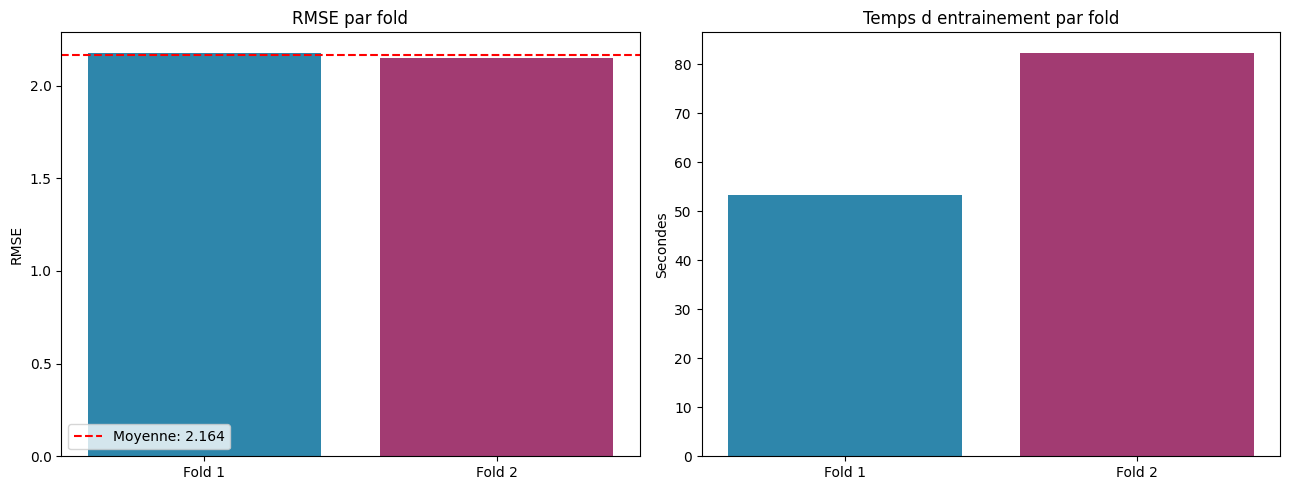

In [22]:
labels_folds = ["Fold " + str(r["fold"]) for r in resultats_folds]
rmse_vals    = [r["rmse"] for r in resultats_folds]
temps_vals   = [r["temps_s"] for r in resultats_folds]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(labels_folds, rmse_vals, color=["#2E86AB","#A23B72","#F18F01"])
axes[0].axhline(rmse_moyen, color="red", linestyle="--", label="Moyenne: " + str(round(rmse_moyen,3)))
axes[0].set_title("RMSE par fold")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].bar(labels_folds, temps_vals, color=["#2E86AB","#A23B72","#F18F01"])
axes[1].set_title("Temps d entrainement par fold")
axes[1].set_ylabel("Secondes")

plt.tight_layout()
plt.show()

## 10. Courbes de Loss par fold — détection sur/sous-apprentissage

Pour chaque fold, on trace train vs validation. Un **sur-apprentissage** se manifeste par une
courbe de validation qui remonte alors que le train continue de baisser. Un **sous-apprentissage**
se manifeste par les deux courbes qui restent élevées et ne convergent pas.

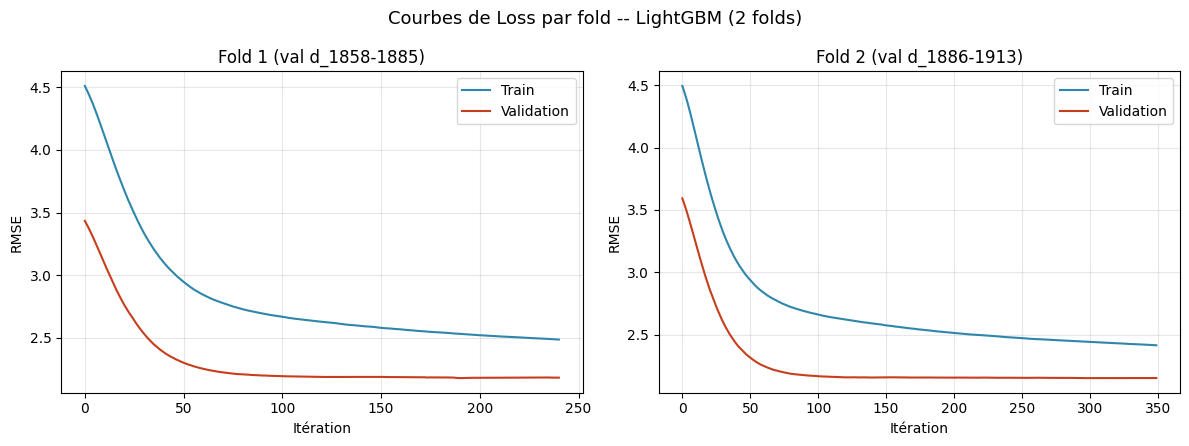

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (evals_result, fold) in enumerate(zip(historiques_loss, FOLDS)):
    axes[i].plot(evals_result["train"]["rmse"], label="Train", color="#2E86AB")
    axes[i].plot(evals_result["valid"]["rmse"], label="Validation", color="#C73E1D")
    titre = f"Fold {i+1} (val d_{fold['val_start']}-{fold['val_end']})"
    axes[i].set_title(titre)
    axes[i].set_xlabel("Itération")
    axes[i].set_ylabel("RMSE")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Courbes de Loss par fold -- LightGBM (2 folds)", fontsize=13)
plt.tight_layout()
plt.show()


In [24]:
# ── Diagnostic automatique sur/sous-apprentissage ──
print("DIAGNOSTIC PAR FOLD")
print("="*55)
for i, evals_result in enumerate(historiques_loss, 1):
    train_final = evals_result["train"]["rmse"][-1]
    valid_final = evals_result["valid"]["rmse"][-1]
    valid_min   = min(evals_result["valid"]["rmse"])
    ecart_relatif = (valid_final - train_final) / train_final * 100

    print("Fold", i, ":")
    print("  RMSE train final     :", round(train_final, 4))
    print("  RMSE valid final     :", round(valid_final, 4))
    print("  RMSE valid minimum   :", round(valid_min, 4))
    print("  Ecart train/valid    :", round(ecart_relatif, 1), "%")

    if ecart_relatif > 50:
        print("  -> Ecart important : possible sur-apprentissage, verifier regularisation")
    elif train_final > 5 and valid_final > 5:
        print("  -> RMSE eleve sur train ET valid : possible sous-apprentissage")
    else:
        print("  -> Ecart raisonnable, pas de signe clair de sur/sous-apprentissage")
    print()

DIAGNOSTIC PAR FOLD
Fold 1 :
  RMSE train final     : 2.4859
  RMSE valid final     : 2.1818
  RMSE valid minimum   : 2.178
  Ecart train/valid    : -12.2 %
  -> Ecart raisonnable, pas de signe clair de sur/sous-apprentissage

Fold 2 :
  RMSE train final     : 2.414
  RMSE valid final     : 2.1511
  RMSE valid minimum   : 2.1506
  Ecart train/valid    : -10.9 %
  -> Ecart raisonnable, pas de signe clair de sur/sous-apprentissage



## 11. Prévisions vs Réel — Fold 3 (la vraie vérité terrain, jours 1914-1941)

Le Fold 3 est le plus représentatif de notre cas d'usage réel : entraîné sur tout l'historique
disponible avant le mois à prédire (1 à 1913), évalué sur les 28 jours suivants jamais vus.

In [25]:
# ── Nombre de rounds final = médiane des 2 folds ──────────────────────────
best_iters       = [r["best_iteration"] for r in resultats_folds]
num_rounds_final = int(np.median(best_iters))
print(f"best_iterations : {best_iters}")
print(f"Rounds final    : {num_rounds_final}")

# ── Réentraînement final sur d_1-{TRAIN_END} ─────────────────────────────────────
print(f"\nRéentraînement final sur d_1-{TRAIN_END} avec {num_rounds_final} rounds...")
train_final_mask = grid_df["d"] <= TRAIN_END
train_final_df   = grid_df.loc[train_final_mask].copy()
train_final_df[TARGET] = train_final_df[TARGET].fillna(0)
X_final = train_final_df[FEATURES]
y_final = train_final_df[TARGET]
print(f"  Lignes : {len(X_final):,}")

final_params    = dict(ACTIVE_PARAMS)
train_final_set = lgb.Dataset(X_final, label=y_final,
                               categorical_feature=CAT_FEATURES_ACTIVE)
modele_final = lgb.train(
    final_params, train_final_set,
    num_boost_round=num_rounds_final,
    callbacks=[lgb.log_evaluation(period=100)]
)
del train_final_df, X_final, y_final, train_final_set
gc.collect()
print("Réentraînement terminé.")

# ── Construction des features pour d_1914-1941 ────────────────────────────
print("\nConstruction des features pour d_1914-1941 ...")

# ids_meta : uniquement id pour construire les lignes futures
ids_meta = grid_df[["id"]].drop_duplicates("id").copy()

# Lignes vides pour d_1914-1941
future_rows = []
for d_val in range(PRED_START, PRED_END + 1):
    tmp = ids_meta.copy()
    tmp["d"]    = d_val
    tmp[TARGET] = np.nan
    future_rows.append(tmp)
future_df = pd.concat(future_rows, ignore_index=True)
del future_rows

# Grille étendue : historique sales + futur vide
grid_for_lags = grid_df[["id","d",TARGET]].copy()
grid_extended = pd.concat([grid_for_lags, future_df], ignore_index=True)
grid_extended = grid_extended.sort_values(["id","d"]).reset_index(drop=True)
del future_df, grid_for_lags
gc.collect()

# ── Lags 28-42 ────────────────────────────────────────────────────────────
lags_ext = grid_extended.copy()
LAG_DAYS = list(range(SHIFT_DAY, SHIFT_DAY + 15))
for l in LAG_DAYS:
    lags_ext[f"{TARGET}_lag_{l}"] = lags_ext.groupby("id")[TARGET]\
        .transform(lambda x, _l=l: x.shift(_l)).astype(np.float16)

# ── Rolling means shift=28 ────────────────────────────────────────────────
for window in [7, 14, 30, 60, 180]:
    lags_ext[f"rolling_mean_{window}"] = lags_ext.groupby("id")[TARGET]\
        .transform(lambda x, _w=window: x.shift(SHIFT_DAY).rolling(_w).mean()).astype(np.float16)
    lags_ext[f"rolling_std_{window}"]  = lags_ext.groupby("id")[TARGET]\
        .transform(lambda x, _w=window: x.shift(SHIFT_DAY).rolling(_w).std()).astype(np.float16)

# ── Rolling ext shift=35,42 ───────────────────────────────────────────────
for d_shift in [35, 42]:
    for d_window in [7, 14, 30, 60]:
        col = f"rolling_mean_ext_{d_shift}_{d_window}"
        lags_ext[col] = lags_ext.groupby("id")[TARGET]\
            .transform(lambda x, _s=d_shift, _w=d_window: x.shift(_s).rolling(_w).mean()).astype(np.float16)

# Garder uniquement d_1914-1941
pred_lags = lags_ext[lags_ext["d"].between(PRED_START, PRED_END)].copy()
del lags_ext, grid_extended
gc.collect()
print(f"pred_lags shape après lags : {pred_lags.shape}")

# ── Merger calendrier ──────────────────────────────────────────────────────
# Recharger le calendrier brut pour avoir les vraies valeurs string
calendar_raw = pd.read_csv(PATH_CALENDAR)

cal_pred = calendar_raw[["d","date","wday","month","year",
                           "event_name_1","event_type_1","event_name_2","event_type_2",
                           "snap_CA","wm_yr_wk"]].copy()
cal_pred["d_num"] = cal_pred["d"].str.extract(r"(\d+)").astype(int)

pred_lags = pred_lags.merge(
    cal_pred.drop(columns=["d"]).rename(columns={"d_num":"d"}),
    on="d", how="left"
)
del cal_pred

# ── Encoder les events avec LES MÊMES catégories que cell 15 ──────────────
# cell 15 fait : grid_df[col] = grid_df[col].astype("category").cat.codes
# Le mapping est basé sur TOUTES les valeurs du calendrier complet
# → on utilise calendar_raw pour construire exactement les mêmes catégories
for col in ["event_name_1","event_type_1","event_name_2","event_type_2"]:
    # Catégories construites sur le calendrier complet (même base que cell 15)
    all_categories = pd.Categorical(calendar_raw[col]).categories
    pred_lags[col] = pd.Categorical(
        pred_lags[col], categories=all_categories
    ).codes.astype(np.int16)

del calendar_raw

pred_lags["date"]         = pd.to_datetime(pred_lags["date"])
pred_lags["jour_semaine"] = pred_lags["date"].dt.dayofweek
pred_lags["jour_du_mois"] = pred_lags["date"].dt.day

# ── Vérification encodage Mother's day ────────────────────────────────────
jour_md_grid = grid_df[grid_df["d"] == 100]["event_name_1"].values[0]
pred_md      = pred_lags[pred_lags["date"] == pd.Timestamp(str(pd.read_csv(PATH_CALENDAR)[pd.read_csv(PATH_CALENDAR)["event_name_1"] == "Mother's day"]["date"].iloc[-1]))]["event_name_1"].values
print(f"Code Mother's day dans grid_df (d_100) : {jour_md_grid}")
print(f"Code Mother's day dans pred_lags       : {pred_md[:3] if len(pred_md) > 0 else 'ABSENT'}")

# ── Merger prix via item_id extrait de id ─────────────────────────────────
pred_lags["item_id_str"] = pred_lags["id"].str.replace(SUFFIX_ID, "", regex=False)

prices_to_merge = prices_df[["item_id","wm_yr_wk","sell_price",
                               "price_max","price_min","price_std","price_mean",
                               "price_nunique","price_norm","price_momentum"]].copy()
prices_to_merge["wm_yr_wk"] = prices_to_merge["wm_yr_wk"].astype(np.int32)
pred_lags["wm_yr_wk"]       = pred_lags["wm_yr_wk"].astype(np.int32)
prices_to_merge = prices_to_merge.rename(columns={"item_id": "item_id_str"})

pred_lags = pred_lags.merge(prices_to_merge, on=["item_id_str","wm_yr_wk"], how="left")
del prices_to_merge

print(f"sell_price non-NaN : {pred_lags['sell_price'].notna().sum()} / {len(pred_lags)}")

# ── Récupérer les codes entiers depuis grid_df via id ─────────────────────
id_to_codes = grid_df[["id","item_id","dept_id","cat_id","store_id","state_id"]]\
    .drop_duplicates("id").set_index("id")

pred_lags["item_id"]  = pred_lags["id"].map(id_to_codes["item_id"]).astype(np.int16)
pred_lags["dept_id"]  = pred_lags["id"].map(id_to_codes["dept_id"]).astype(np.int16)
pred_lags["cat_id"]   = pred_lags["id"].map(id_to_codes["cat_id"]).astype(np.int16)
pred_lags["store_id"] = pred_lags["id"].map(id_to_codes["store_id"]).astype(np.int16)
pred_lags["state_id"] = pred_lags["id"].map(id_to_codes["state_id"]).astype(np.int16)

# Nettoyer colonne temporaire
pred_lags = pred_lags.drop(columns=["item_id_str"])

pred_lags = reduce_mem_usage(pred_lags, verbose=False)

# ── Vérification features ──────────────────────────────────────────────────
missing = [f for f in FEATURES if f not in pred_lags.columns]
if missing:
    print(f"⚠ Features manquantes ({len(missing)}) : {missing}")
else:
    print(f"✓ Toutes les {len(FEATURES)} features présentes")

# ── Prédiction finale ──────────────────────────────────────────────────────
print()
print("="*60)
print("PRÉDICTION FINALE : d_1914 → d_1941")
print("(jamais vus pendant l'entraînement ni la validation)")
print("="*60)

X_pred = pred_lags[FEATURES]
print(f"X_pred shape : {X_pred.shape}")

predictions             = np.maximum(0, modele_final.predict(X_pred))
pred_lags["prediction"] = predictions
pred_df                 = pred_lags.copy()

print(f"Lignes prédites  : {len(pred_df)}")
print(f"Produits prédits : {pred_df['id'].nunique()}")

best_iterations : [191, 300]
Rounds final    : 245

Réentraînement final sur d_1-1885 avec 245 rounds...
  Lignes : 4,617,523
Réentraînement terminé.

Construction des features pour d_1914-1941 ...
pred_lags shape après lags : (85372, 36)
Code Mother's day dans grid_df (d_100) : 15
Code Mother's day dans pred_lags       : [15 15 15]
sell_price non-NaN : 100617 / 100617
✓ Toutes les 56 features présentes

PRÉDICTION FINALE : d_1914 → d_1941
(jamais vus pendant l'entraînement ni la validation)
X_pred shape : (100617, 56)
Lignes prédites  : 100617
Produits prédits : 3049


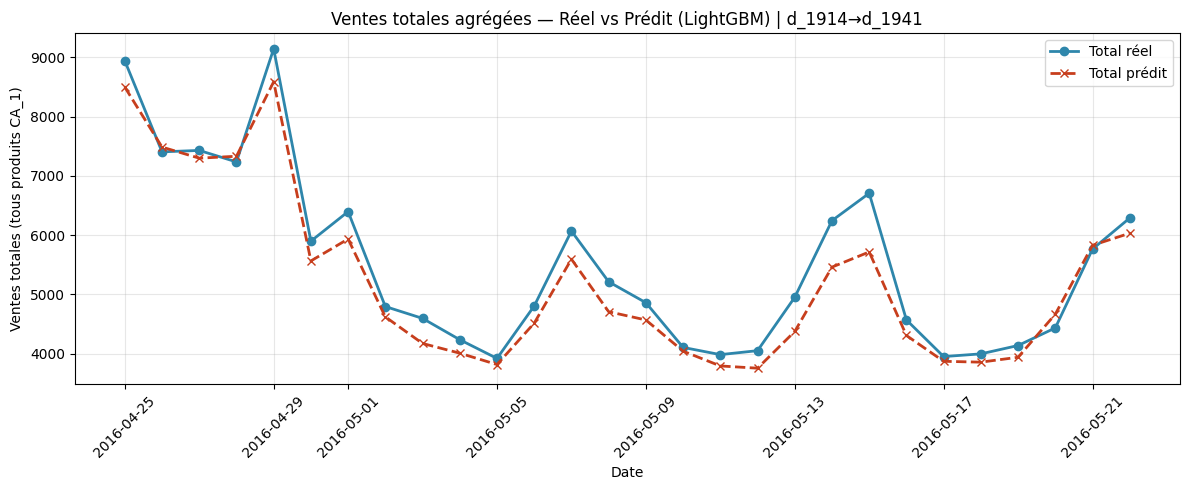

In [26]:
# ── Graphe 3 : ventes totales agrégées par jour ──────────────────────────
# Merger prédictions + vérité terrain depuis verite_df
verite_long = verite_df.melt(
    id_vars=["id","item_id","dept_id","cat_id","store_id","state_id"],
    var_name="d_str", value_name="reel"
)
verite_long["d"] = verite_long["d_str"].str.extract(r"(\d+)").astype(int)
verite_long = verite_long[["id","d","reel"]]

pred_eval = pred_df[["id","d","date","prediction"]].copy()
pred_eval["d"] = pred_eval["d"].astype(int)
pred_eval = pred_eval.merge(verite_long, on=["id","d"], how="left")

# Agrégation journalière
agg_jour = pred_eval.groupby("date")[["reel","prediction"]].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(agg_jour["date"], agg_jour["reel"],       marker="o", label="Total réel",
         color="#2E86AB", linewidth=2)
plt.plot(agg_jour["date"], agg_jour["prediction"], marker="x", label="Total prédit",
         color="#C73E1D", linewidth=2, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Ventes totales (tous produits CA_1)")
plt.title(f"Ventes totales agrégées — Réel vs Prédit (LightGBM) | d_{PRED_START}→d_{PRED_END}")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Importance des features

Vérification de cohérence : les features de lag/rolling les plus proches de 28 jours et
les features de prix doivent dominer — un signe que le modèle apprend des patterns sensés
plutôt que du bruit.

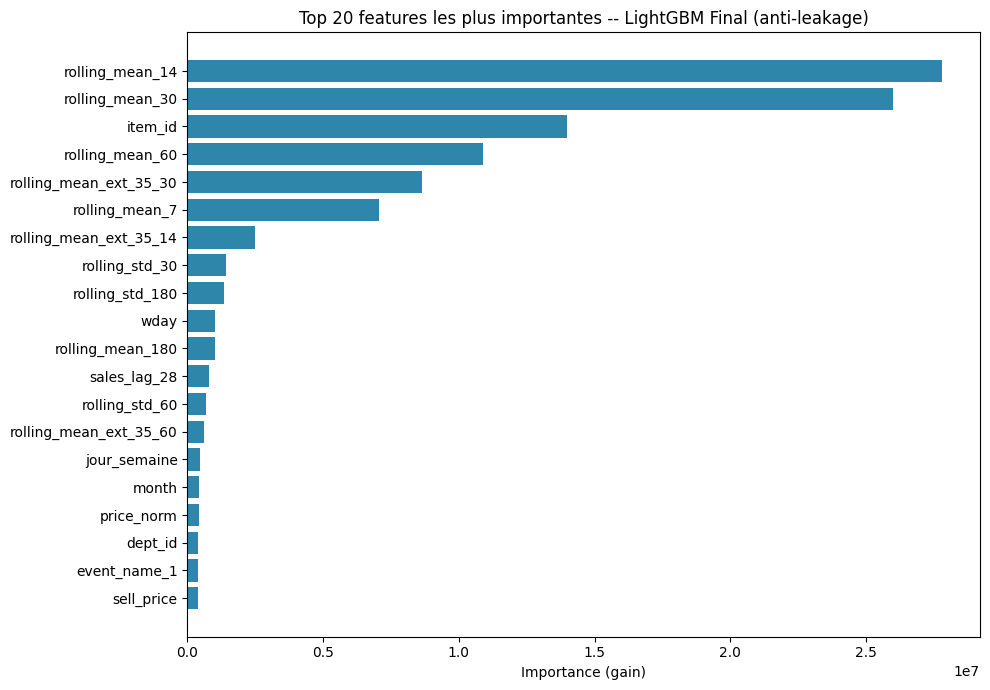

,feature,importance
40,rolling_mean_14,2.781289e+07
42,rolling_mean_30,2.601358e+07
0,item_id,1.399113e+07
44,rolling_mean_60,1.089643e+07
50,rolling_mean_ext_35_30,8.654726e+06
38,rolling_mean_7,7.070853e+06
49,rolling_mean_ext_35_14,2.473227e+06
43,rolling_std_30,1.412937e+06
47,rolling_std_180,1.337578e+06
13,wday,1.023996e+06


In [27]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": modele_final.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#2E86AB")
plt.xlabel("Importance (gain)")
plt.title("Top 20 features les plus importantes -- LightGBM Final (anti-leakage)")
plt.tight_layout()
plt.show()

display(importance_df)

## Comparaison finale : Somme ventes réelles vs prédites par produit (d_1914→d_1941)

Évaluation **propre** : aucune donnée de 1914–1941 n'a été vue pendant l'entraînement.

SOMME DES VENTES : RÉEL vs PRÉDIT  (d_1914 → d_1941)
Nb produits         : 3049
Total réel          : 154,113
Total prédit        : 146,323.8
Ratio prédit/réel   : 0.9495
Écart global        : -7789.2 unités

✓ comparaison_somme_par_produit.csv sauvegardé
✓ Graphique sauvegardé : C:\Users\ayady\Downloads\prediction\comparaison_somme_finale.png


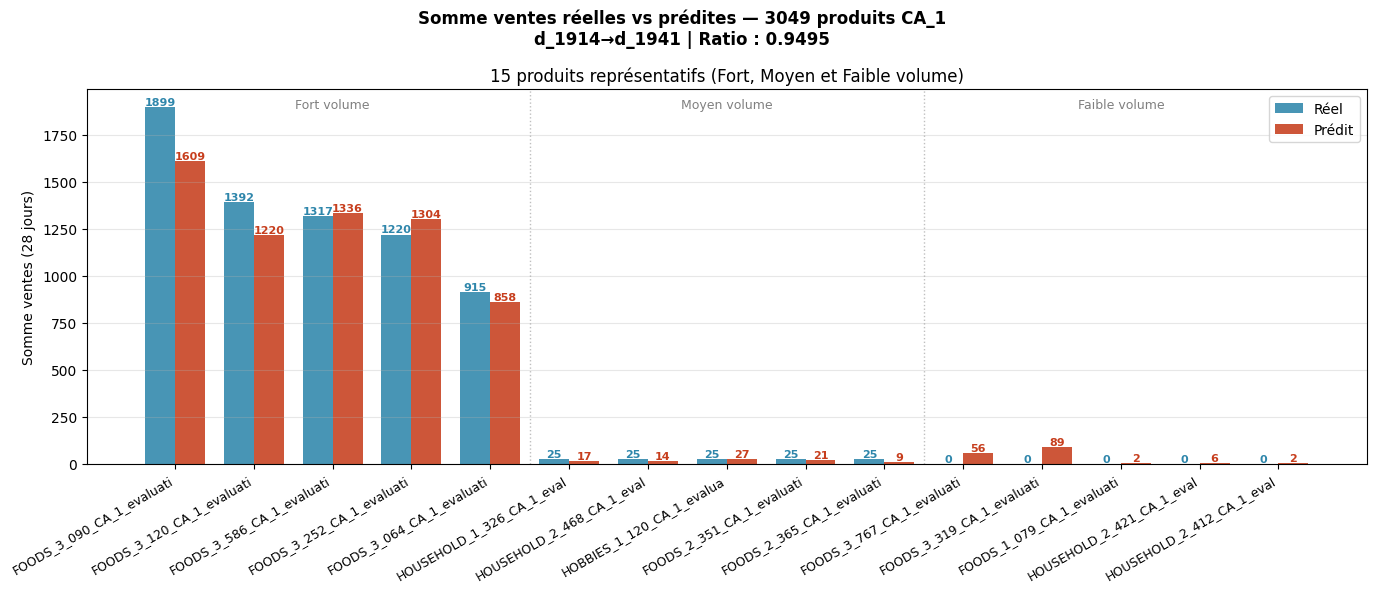

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPARAISON FINALE : SOMME VENTES RÉELLES vs PRÉDITES PAR PRODUIT
# d_1914 → d_1941
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ── 1. Construire pred_eval (prédictions + vérité terrain) ────────────────
verite_long = verite_df.melt(
    id_vars=["id","item_id","dept_id","cat_id","store_id","state_id"],
    var_name="d_str", value_name="reel"
)
verite_long["d"] = verite_long["d_str"].str.extract(r"(\d+)").astype(int)
verite_long = verite_long[["id","d","reel"]]

pred_eval = pred_df[["id","d","prediction"]].copy()
pred_eval["d"] = pred_eval["d"].astype(int)
pred_eval = pred_eval.merge(verite_long, on=["id","d"], how="left")

# ── 2. Somme par produit ──────────────────────────────────────────────────
somme = (
    pred_eval
    .groupby("id")[["reel","prediction"]]
    .sum()
    .reset_index()
)
somme = somme.sort_values("reel", ascending=False).reset_index(drop=True)

# ── 3. Métriques globales ─────────────────────────────────────────────────
total_reel   = somme["reel"].sum()
total_predit = somme["prediction"].sum()
ratio        = total_predit / total_reel

print("="*65)
print(f"SOMME DES VENTES : RÉEL vs PRÉDIT  (d_{PRED_START} → d_{PRED_END})")
print("="*65)
print(f"Nb produits         : {len(somme)}")
print(f"Total réel          : {total_reel:,.0f}")
print(f"Total prédit        : {total_predit:,.1f}")
print(f"Ratio prédit/réel   : {ratio:.4f}")
print(f"Écart global        : {total_predit - total_reel:+.1f} unités")

if 'OUTPUT_DIR' in globals():
    somme.to_csv(os.path.join(OUTPUT_DIR, "comparaison_somme_par_produit.csv"), index=False)
    print(f"\n✓ comparaison_somme_par_produit.csv sauvegardé")

# ── 4. Graphique 15 produits représentatifs ───────────────────────────────
n = len(somme)
sample = pd.concat([
    somme.head(5),
    somme.iloc[n//2-2 : n//2+3],
    somme.tail(5)
]).drop_duplicates("id").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    f"Somme ventes réelles vs prédites — {len(somme)} produits CA_1\n"
    f"d_{PRED_START}→d_{PRED_END} | Ratio : {ratio:.4f}",
    fontsize=12, fontweight="bold"
)

x, width = np.arange(len(sample)), 0.38

bars_r = ax.bar(x - width/2, sample["reel"],       width, label="Réel",   color="#2E86AB", alpha=0.88)
bars_p = ax.bar(x + width/2, sample["prediction"], width, label="Prédit", color="#C73E1D", alpha=0.88)

for bar in bars_r:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{int(h)}",
            ha="center", va="bottom", fontsize=8, color="#2E86AB", fontweight="bold")
for bar in bars_p:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{h:.0f}",
            ha="center", va="bottom", fontsize=8, color="#C73E1D", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sample["id"]], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Somme ventes (28 jours)")
ax.set_title("15 produits représentatifs (Fort, Moyen et Faible volume)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for sep in [4.5, 9.5]:
    ax.axvline(sep, color="gray", lw=1, linestyle=":", alpha=0.5)
    
ymax_ax = ax.get_ylim()[1]
ax.text(2,  ymax_ax*0.95, "Fort volume",   ha="center", fontsize=9, color="gray")
ax.text(7,  ymax_ax*0.95, "Moyen volume",  ha="center", fontsize=9, color="gray")
ax.text(12, ymax_ax*0.95, "Faible volume", ha="center", fontsize=9, color="gray")

plt.tight_layout()

if 'OUTPUT_DIR' in globals():
    fig_path = os.path.join(OUTPUT_DIR, "comparaison_somme_finale.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"✓ Graphique sauvegardé : {fig_path}")

plt.show()

=== FOODS_3_767 ===
Historique (d_1-1885)   : total=12001  moy/j=6.37
Mois (1886-1913)         : total=9  moy/j=0.32
Vérité (1914-1941)       : total=0  moy/j=0.00

✓ Graphique sauvegardé : C:\Users\ayady\Downloads\prediction\evolution_FOODS_3_767.png


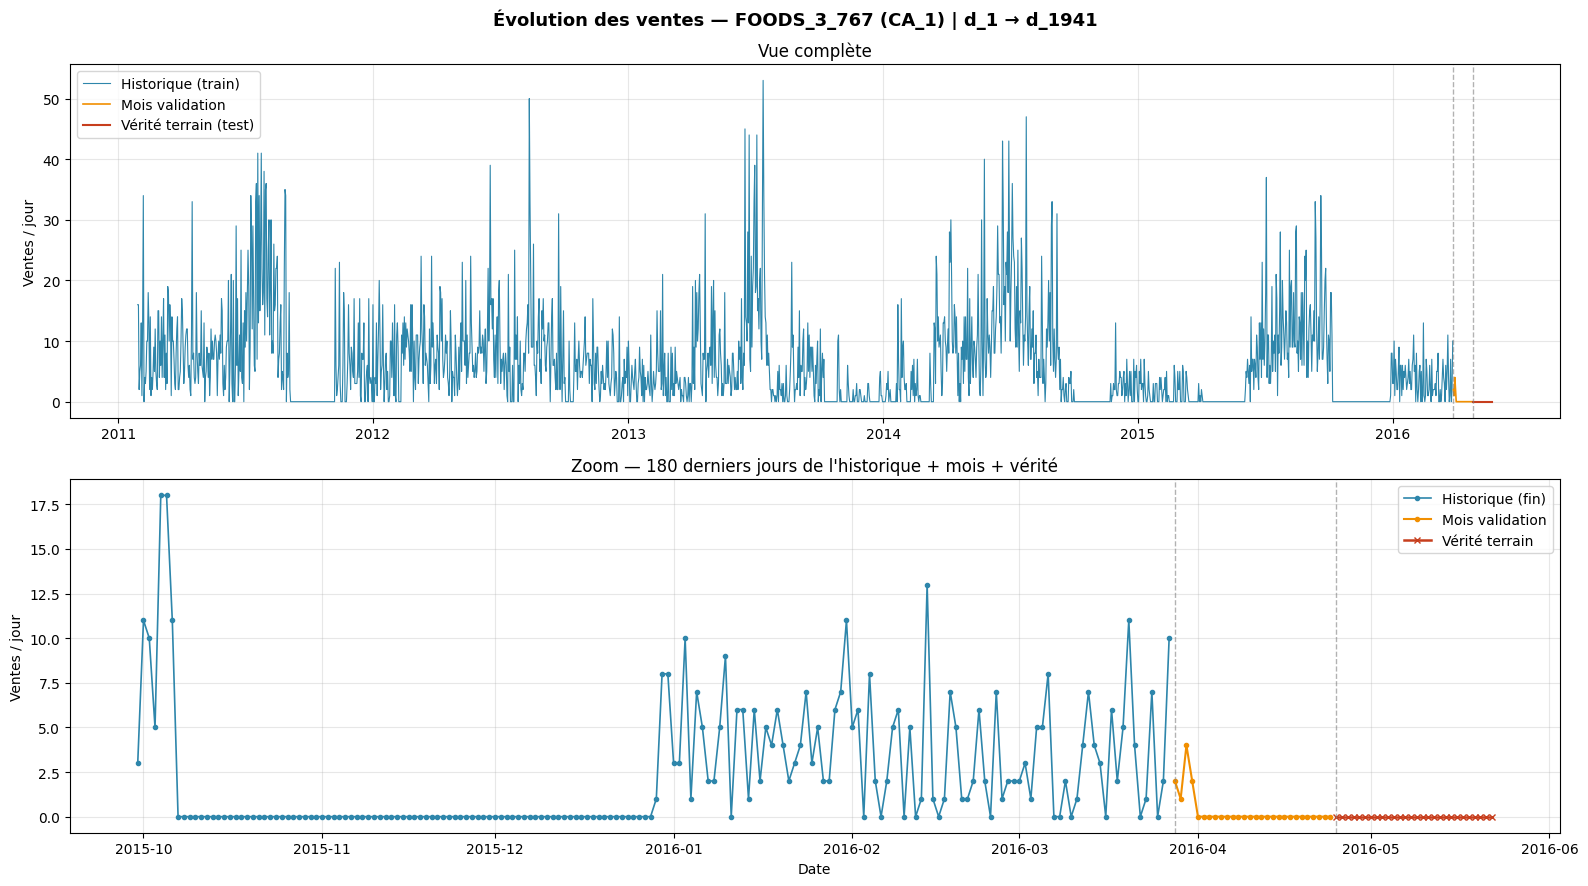

In [29]:
# ══════════════════════════════════════════════════════════════════════════
# VISUALISATION : Évolution des ventes de FOODS_3_767 (d_1 → d_1941)
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import os

ITEM_CIBLE = "FOODS_3_767"

# ── Chargement ──────────────────────────────────────────────────────────────
hist_sales  = pd.read_csv(os.path.join(TRAIN_DIR, "historique_sales_CA1.csv"))
mois_sales  = pd.read_csv(os.path.join(TEST_DIR,  "sales_du_mois_CA1.csv"))
verite      = pd.read_csv(os.path.join(TEST_DIR,  "verite_terrain_CA1.csv"))
cal         = pd.read_csv(os.path.join(TRAIN_DIR, "calendar.csv"))

# ── Vérifier que le produit existe ─────────────────────────────────────────
if ITEM_CIBLE not in hist_sales["item_id"].values:
    print(f"⚠ {ITEM_CIBLE} n'est pas dans le sous-ensemble sélectionné.")
    print(f"Quelques exemples disponibles : {hist_sales['item_id'].unique()[:10].tolist()}")
else:
    # ── Extraire la série complète pour ce produit ──────────────────────────
    row_hist   = hist_sales[hist_sales["item_id"] == ITEM_CIBLE]
    row_mois   = mois_sales[mois_sales["item_id"] == ITEM_CIBLE]
    row_verite = verite[verite["item_id"] == ITEM_CIBLE]

    day_hist   = sorted([c for c in hist_sales.columns if c.startswith("d_")], key=lambda x: int(x[2:]))
    day_mois   = sorted([c for c in mois_sales.columns if c.startswith("d_")], key=lambda x: int(x[2:]))
    day_verite = sorted([c for c in verite.columns if c.startswith("d_")], key=lambda x: int(x[2:]))

    vals_hist   = row_hist[day_hist].values.flatten()
    vals_mois   = row_mois[day_mois].values.flatten()
    vals_verite = row_verite[day_verite].values.flatten()

    days_hist_num   = [int(d[2:]) for d in day_hist]
    days_mois_num   = [int(d[2:]) for d in day_mois]
    days_verite_num = [int(d[2:]) for d in day_verite]

    # ── Merger avec les dates calendrier ────────────────────────────────────
    cal["d_num"] = cal["d"].str.extract(r"(\d+)").astype(int)
    cal_map = cal.set_index("d_num")["date"]

    dates_hist   = pd.to_datetime(cal_map.loc[days_hist_num].values)
    dates_mois   = pd.to_datetime(cal_map.loc[days_mois_num].values)
    dates_verite = pd.to_datetime(cal_map.loc[days_verite_num].values)

    # ── Stats globales ──────────────────────────────────────────────────────
    print(f"=== {ITEM_CIBLE} ===")
    print(f"Historique (d_1-{days_hist_num[-1]})   : total={vals_hist.sum():.0f}  moy/j={vals_hist.mean():.2f}")
    print(f"Mois ({days_mois_num[0]}-{days_mois_num[-1]})         : total={vals_mois.sum():.0f}  moy/j={vals_mois.mean():.2f}")
    print(f"Vérité ({days_verite_num[0]}-{days_verite_num[-1]})       : total={vals_verite.sum():.0f}  moy/j={vals_verite.mean():.2f}")

    # ── Graphique 1 : vue complète d_1 → d_1941 ─────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(f"Évolution des ventes — {ITEM_CIBLE} (CA_1) | d_1 → d_1941",
                 fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.plot(dates_hist,   vals_hist,   color="#2E86AB", lw=0.8, label="Historique (train)")
    ax.plot(dates_mois,   vals_mois,   color="#F18F01", lw=1.2, label="Mois validation")
    ax.plot(dates_verite, vals_verite, color="#C73E1D", lw=1.5, label="Vérité terrain (test)")
    ax.axvline(dates_mois[0],   color="gray", linestyle="--", lw=1, alpha=0.6)
    ax.axvline(dates_verite[0], color="gray", linestyle="--", lw=1, alpha=0.6)
    ax.set_ylabel("Ventes / jour")
    ax.set_title("Vue complète")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Graphique 2 : zoom sur les 180 derniers jours ───────────────────────
    ax2 = axes[1]
    zoom_n = 180
    dates_zoom_hist = dates_hist[-zoom_n:] if len(dates_hist) > zoom_n else dates_hist
    vals_zoom_hist  = vals_hist[-zoom_n:]  if len(vals_hist)  > zoom_n else vals_hist

    ax2.plot(dates_zoom_hist, vals_zoom_hist, color="#2E86AB", lw=1.2, marker=".", label="Historique (fin)")
    ax2.plot(dates_mois,   vals_mois,   color="#F18F01", lw=1.5, marker="o", markersize=3, label="Mois validation")
    ax2.plot(dates_verite, vals_verite, color="#C73E1D", lw=1.8, marker="x", markersize=4, label="Vérité terrain")
    ax2.axvline(dates_mois[0],   color="gray", linestyle="--", lw=1, alpha=0.6)
    ax2.axvline(dates_verite[0], color="gray", linestyle="--", lw=1, alpha=0.6)
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Ventes / jour")
    ax2.set_title(f"Zoom — {zoom_n} derniers jours de l'historique + mois + vérité")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if 'OUTPUT_DIR' in globals():
        fig_path = os.path.join(OUTPUT_DIR, f"evolution_{ITEM_CIBLE}.png")
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"\n✓ Graphique sauvegardé : {fig_path}")
    plt.show()

del hist_sales, mois_sales, verite, cal

=== FOODS_1_079 ===
Historique (d_1-1885)   : total=82  moy/j=0.04
Mois (1886-1913)         : total=0  moy/j=0.00
Vérité (1914-1941)       : total=0  moy/j=0.00

✓ Graphique sauvegardé : C:\Users\ayady\Downloads\prediction\evolution_FOODS_1_079.png


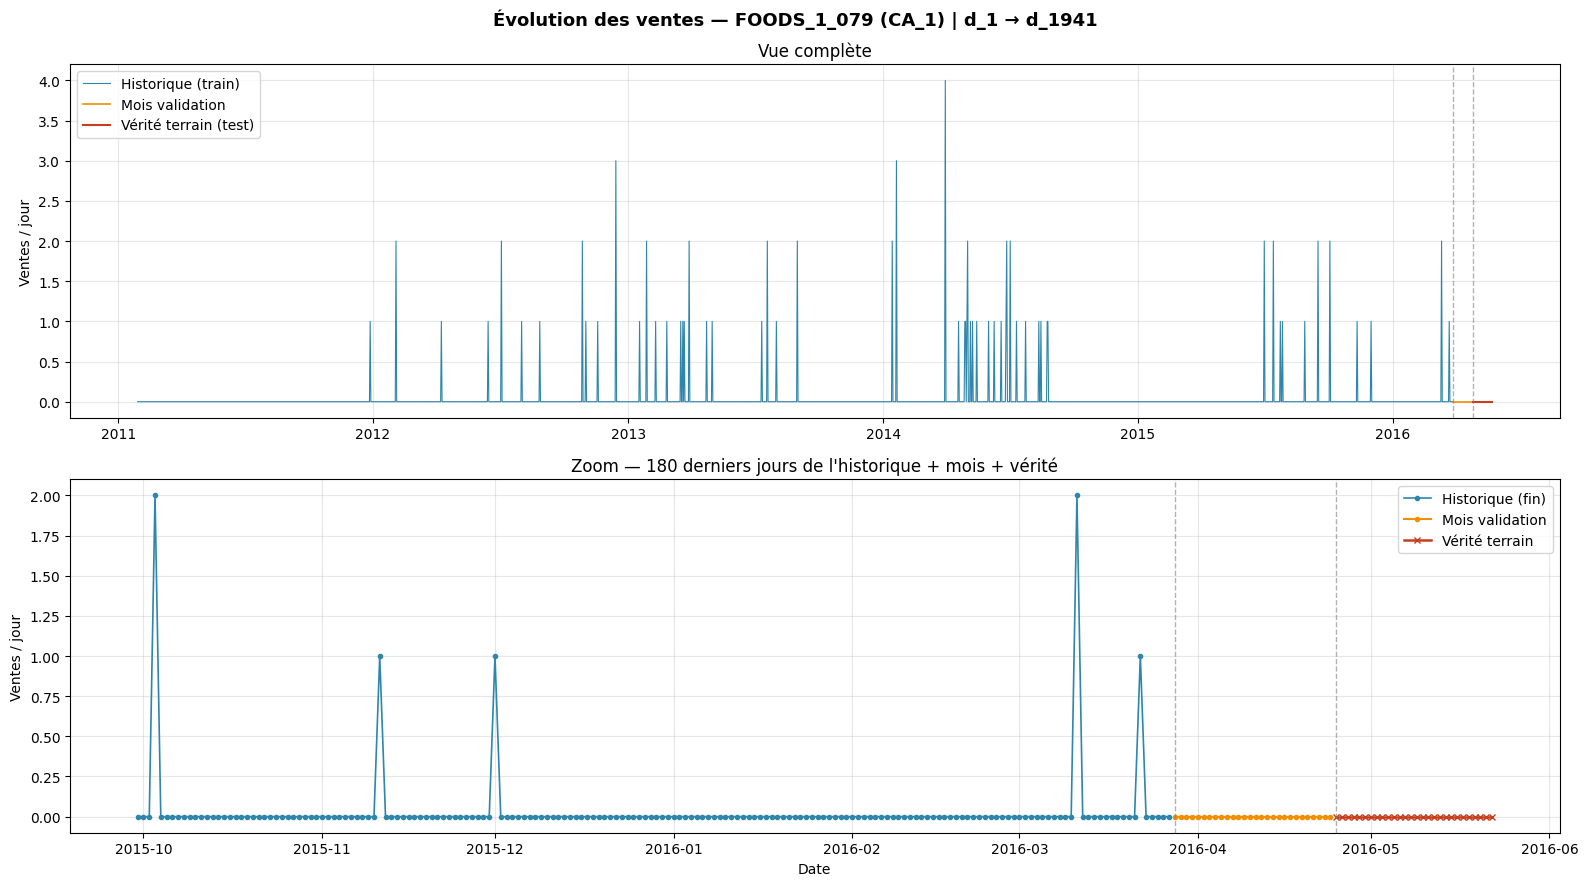

In [30]:
# ══════════════════════════════════════════════════════════════════════════
# VISUALISATION : Évolution des ventes de FOODS_1_079 (d_1 → d_1941)
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import os

ITEM_CIBLE = "FOODS_1_079"

# ── Chargement ──────────────────────────────────────────────────────────────
hist_sales  = pd.read_csv(os.path.join(TRAIN_DIR, "historique_sales_CA1.csv"))
mois_sales  = pd.read_csv(os.path.join(TEST_DIR,  "sales_du_mois_CA1.csv"))
verite      = pd.read_csv(os.path.join(TEST_DIR,  "verite_terrain_CA1.csv"))
cal         = pd.read_csv(os.path.join(TRAIN_DIR, "calendar.csv"))

# ── Vérifier que le produit existe ─────────────────────────────────────────
if ITEM_CIBLE not in hist_sales["item_id"].values:
    print(f"⚠ {ITEM_CIBLE} n'est pas dans le sous-ensemble sélectionné.")
    print(f"Quelques exemples disponibles : {hist_sales['item_id'].unique()[:10].tolist()}")
else:
    # ── Extraire la série complète pour ce produit ──────────────────────────
    row_hist   = hist_sales[hist_sales["item_id"] == ITEM_CIBLE]
    row_mois   = mois_sales[mois_sales["item_id"] == ITEM_CIBLE]
    row_verite = verite[verite["item_id"] == ITEM_CIBLE]

    day_hist   = sorted([c for c in hist_sales.columns if c.startswith("d_")], key=lambda x: int(x[2:]))
    day_mois   = sorted([c for c in mois_sales.columns if c.startswith("d_")], key=lambda x: int(x[2:]))
    day_verite = sorted([c for c in verite.columns if c.startswith("d_")], key=lambda x: int(x[2:]))

    vals_hist   = row_hist[day_hist].values.flatten()
    vals_mois   = row_mois[day_mois].values.flatten()
    vals_verite = row_verite[day_verite].values.flatten()

    days_hist_num   = [int(d[2:]) for d in day_hist]
    days_mois_num   = [int(d[2:]) for d in day_mois]
    days_verite_num = [int(d[2:]) for d in day_verite]

    # ── Merger avec les dates calendrier ────────────────────────────────────
    cal["d_num"] = cal["d"].str.extract(r"(\d+)").astype(int)
    cal_map = cal.set_index("d_num")["date"]

    dates_hist   = pd.to_datetime(cal_map.loc[days_hist_num].values)
    dates_mois   = pd.to_datetime(cal_map.loc[days_mois_num].values)
    dates_verite = pd.to_datetime(cal_map.loc[days_verite_num].values)

    # ── Stats globales ──────────────────────────────────────────────────────
    print(f"=== {ITEM_CIBLE} ===")
    print(f"Historique (d_1-{days_hist_num[-1]})   : total={vals_hist.sum():.0f}  moy/j={vals_hist.mean():.2f}")
    print(f"Mois ({days_mois_num[0]}-{days_mois_num[-1]})         : total={vals_mois.sum():.0f}  moy/j={vals_mois.mean():.2f}")
    print(f"Vérité ({days_verite_num[0]}-{days_verite_num[-1]})       : total={vals_verite.sum():.0f}  moy/j={vals_verite.mean():.2f}")

    # ── Graphique 1 : vue complète d_1 → d_1941 ─────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(f"Évolution des ventes — {ITEM_CIBLE} (CA_1) | d_1 → d_1941",
                 fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.plot(dates_hist,   vals_hist,   color="#2E86AB", lw=0.8, label="Historique (train)")
    ax.plot(dates_mois,   vals_mois,   color="#F18F01", lw=1.2, label="Mois validation")
    ax.plot(dates_verite, vals_verite, color="#C73E1D", lw=1.5, label="Vérité terrain (test)")
    ax.axvline(dates_mois[0],   color="gray", linestyle="--", lw=1, alpha=0.6)
    ax.axvline(dates_verite[0], color="gray", linestyle="--", lw=1, alpha=0.6)
    ax.set_ylabel("Ventes / jour")
    ax.set_title("Vue complète")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Graphique 2 : zoom sur les 180 derniers jours ───────────────────────
    ax2 = axes[1]
    zoom_n = 180
    dates_zoom_hist = dates_hist[-zoom_n:] if len(dates_hist) > zoom_n else dates_hist
    vals_zoom_hist  = vals_hist[-zoom_n:]  if len(vals_hist)  > zoom_n else vals_hist

    ax2.plot(dates_zoom_hist, vals_zoom_hist, color="#2E86AB", lw=1.2, marker=".", label="Historique (fin)")
    ax2.plot(dates_mois,   vals_mois,   color="#F18F01", lw=1.5, marker="o", markersize=3, label="Mois validation")
    ax2.plot(dates_verite, vals_verite, color="#C73E1D", lw=1.8, marker="x", markersize=4, label="Vérité terrain")
    ax2.axvline(dates_mois[0],   color="gray", linestyle="--", lw=1, alpha=0.6)
    ax2.axvline(dates_verite[0], color="gray", linestyle="--", lw=1, alpha=0.6)
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Ventes / jour")
    ax2.set_title(f"Zoom — {zoom_n} derniers jours de l'historique + mois + vérité")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if 'OUTPUT_DIR' in globals():
        fig_path = os.path.join(OUTPUT_DIR, f"evolution_{ITEM_CIBLE}.png")
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"\n✓ Graphique sauvegardé : {fig_path}")
    plt.show()

del hist_sales, mois_sales, verite, cal

SOMME DES VENTES : RÉEL vs BASELINE MENSUELLE (d_1914 → d_1941)
Nb produits         : 3049
Total réel          : 134,032
Total baseline      : 110,651.4
Ratio baseline/réel : 0.8256
Écart global        : -23380.6 unités

✓ comparaison_baseline_mensuelle.csv sauvegardé
✓ Graphique sauvegardé : C:\Users\ayady\Downloads\prediction\comparaison_baseline_mensuelle.png


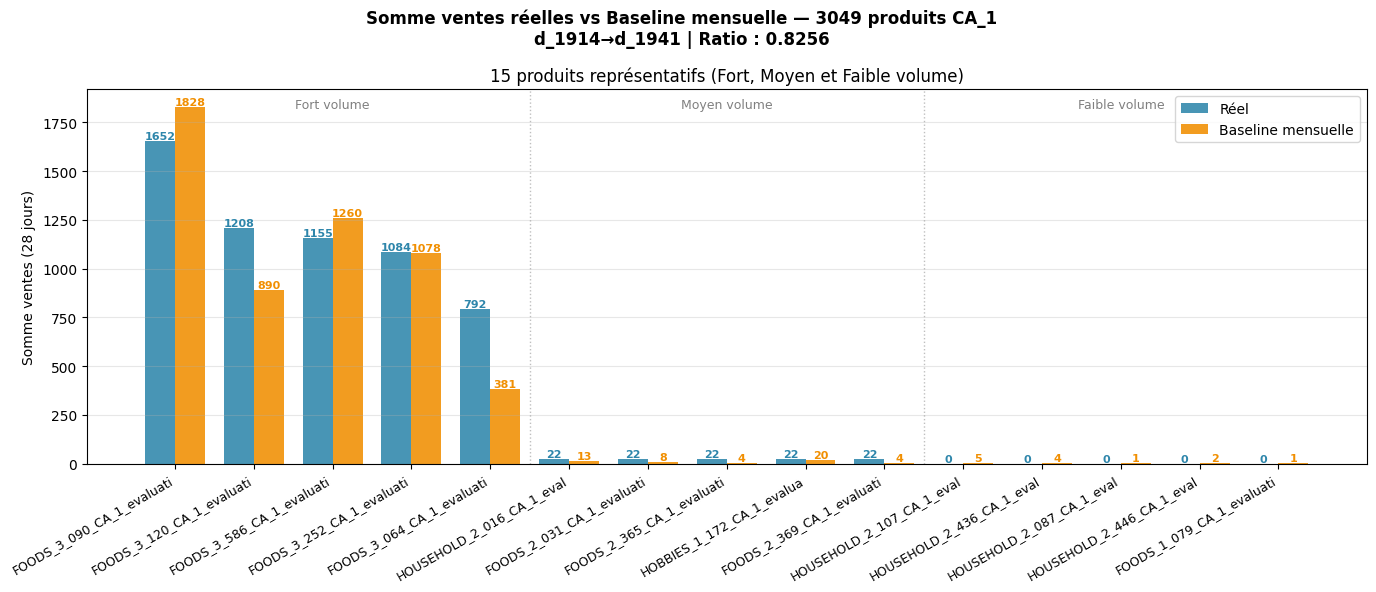

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPARAISON FINALE : SOMME VENTES RÉELLES vs BASELINE (MOYENNE MENSUELLE)
# Baseline : pour chaque produit, moyenne des sommes mensuelles de ventes
#            calculée sur l'historique d_1 → d_1913 (hors 1914-1941)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ── 1. Construire la baseline : moyenne mensuelle par produit ─────────────
hist_sales  = pd.read_csv(PATH_HIST_SALES)
mois_sales  = pd.read_csv(PATH_MOIS_SALES)

sales_hist_full = hist_sales.merge(
    mois_sales.drop(columns=["dept_id","cat_id","store_id","state_id"], errors="ignore"),
    on=["id","item_id"], how="left"
)
del hist_sales, mois_sales

day_cols_hist = [c for c in sales_hist_full.columns if c.startswith("d_")]
sales_long = sales_hist_full[["id"] + day_cols_hist].melt(
    id_vars=["id"], var_name="d_str", value_name="ventes"
)
sales_long["d_num"] = sales_long["d_str"].str.extract(r"(\d+)").astype(int)
sales_long["ventes"] = sales_long["ventes"].fillna(0)
del sales_hist_full

cal_tmp = pd.read_csv(PATH_CALENDAR, usecols=["d","month","year"])
cal_tmp["d_num"] = cal_tmp["d"].str.extract(r"(\d+)").astype(int)
sales_long = sales_long.merge(cal_tmp[["d_num","month","year"]], on="d_num", how="left")
del cal_tmp

sales_long["mois_key"] = sales_long["year"].astype(str) + "-" + sales_long["month"].astype(str).str.zfill(2)

somme_par_mois = (
    sales_long
    .groupby(["id","mois_key"])["ventes"]
    .sum()
    .reset_index()
    .rename(columns={"ventes": "somme_mois"})
)
del sales_long

# Moyenne mensuelle → somme sur 28 jours
nb_jours_pred = PRED_END - PRED_START + 1
ratio_28j = nb_jours_pred / 30.4375

baseline = (
    somme_par_mois
    .groupby("id")["somme_mois"]
    .mean()
    .reset_index()
    .rename(columns={"somme_mois": "prediction"})
)
baseline["prediction"] = (baseline["prediction"] * ratio_28j).round(1)
del somme_par_mois

# ── 2. Vérité terrain ─────────────────────────────────────────────────────
verite_long = verite_df.melt(
    id_vars=["id","item_id","dept_id","cat_id","store_id","state_id"],
    var_name="d_str", value_name="reel"
)
verite_long["d"] = verite_long["d_str"].str.extract(r"(\d+)").astype(int)
verite_long = verite_long[["id","d","reel"]]

reel_par_produit = (
    verite_long
    .groupby("id")["reel"]
    .sum()
    .reset_index()
    .rename(columns={"reel": "reel"})
)

# ── 3. Assembler baseline + réel ──────────────────────────────────────────
somme = reel_par_produit.merge(baseline, on="id", how="left")
somme = somme.sort_values("reel", ascending=False).reset_index(drop=True)
del reel_par_produit, baseline

# ── 4. Métriques globales ─────────────────────────────────────────────────
total_reel   = somme["reel"].sum()
total_predit = somme["prediction"].sum()
ratio        = total_predit / total_reel

print("="*65)
print(f"SOMME DES VENTES : RÉEL vs BASELINE MENSUELLE (d_{PRED_START} → d_{PRED_END})")
print("="*65)
print(f"Nb produits         : {len(somme)}")
print(f"Total réel          : {total_reel:,.0f}")
print(f"Total baseline      : {total_predit:,.1f}")
print(f"Ratio baseline/réel : {ratio:.4f}")
print(f"Écart global        : {total_predit - total_reel:+.1f} unités")

if 'OUTPUT_DIR' in globals():
    somme.to_csv(os.path.join(OUTPUT_DIR, "comparaison_baseline_mensuelle.csv"), index=False)
    print(f"\n✓ comparaison_baseline_mensuelle.csv sauvegardé")

# ── 5. Graphique 15 produits représentatifs ───────────────────────────────
n = len(somme)
sample = pd.concat([
    somme.head(5),
    somme.iloc[n//2-2 : n//2+3],
    somme.tail(5)
]).drop_duplicates("id").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    f"Somme ventes réelles vs Baseline mensuelle — {len(somme)} produits CA_1\n"
    f"d_{PRED_START}→d_{PRED_END} | Ratio : {ratio:.4f}",
    fontsize=12, fontweight="bold"
)

x, width = np.arange(len(sample)), 0.38

bars_r = ax.bar(x - width/2, sample["reel"],       width,
                label="Réel",              color="#2E86AB", alpha=0.88)
bars_p = ax.bar(x + width/2, sample["prediction"], width,
                label="Baseline mensuelle", color="#F18F01", alpha=0.88)

for bar in bars_r:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{int(h)}",
            ha="center", va="bottom", fontsize=8, color="#2E86AB", fontweight="bold")
for bar in bars_p:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{h:.0f}",
            ha="center", va="bottom", fontsize=8, color="#F18F01", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sample["id"]], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Somme ventes (28 jours)")
ax.set_title("15 produits représentatifs (Fort, Moyen et Faible volume)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for sep in [4.5, 9.5]:
    ax.axvline(sep, color="gray", lw=1, linestyle=":", alpha=0.5)

ymax_ax = ax.get_ylim()[1]
ax.text(2,  ymax_ax*0.95, "Fort volume",   ha="center", fontsize=9, color="gray")
ax.text(7,  ymax_ax*0.95, "Moyen volume",  ha="center", fontsize=9, color="gray")
ax.text(12, ymax_ax*0.95, "Faible volume", ha="center", fontsize=9, color="gray")

plt.tight_layout()

if 'OUTPUT_DIR' in globals():
    fig_path = os.path.join(OUTPUT_DIR, "comparaison_baseline_mensuelle.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"✓ Graphique sauvegardé : {fig_path}")

plt.show()

STATS COMPARATIVES — d_1914 → d_1941
Métrique                           Modèle   Baseline
-------------------------------------------------------
Total prédit                      146,324    110,651
Total réel                        134,032    134,032
Ratio prédit/réel                  1.0917     0.8256
Écart global                       +12292     -23381
MAE par produit                     13.34      18.67
RMSE par produit                    31.90      43.94
-------------------------------------------------------
GAIN DU MODÈLE vs BASELINE :
  MAE  réduite de  : +28.5%
  RMSE réduite de  : +27.4%
  Ratio plus proche de 1 : ✓ OUI
  Produits mieux prédits : 1861 / 3049

✓ comparaison_3barres.csv sauvegardé
✓ Graphique sauvegardé : C:\Users\ayady\Downloads\prediction\comparaison_3barres.png


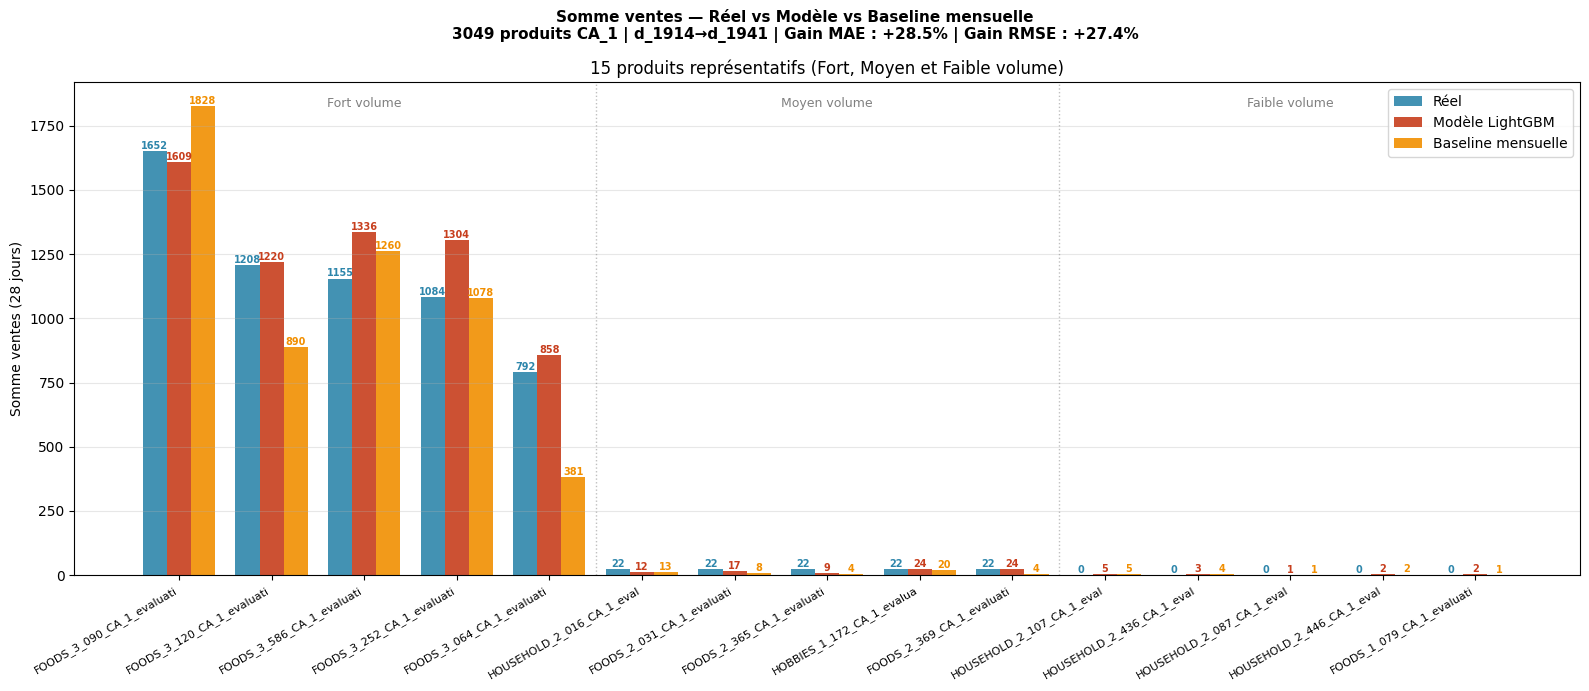

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPARAISON : RÉEL vs PRÉDICTION MODÈLE vs BASELINE MENSUELLE
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ── 1. Baseline mensuelle ─────────────────────────────────────────────────
hist_sales = pd.read_csv(PATH_HIST_SALES)
mois_sales = pd.read_csv(PATH_MOIS_SALES)
sales_hist_full = hist_sales.merge(
    mois_sales.drop(columns=["dept_id","cat_id","store_id","state_id"], errors="ignore"),
    on=["id","item_id"], how="left"
)
del hist_sales, mois_sales

day_cols_hist = [c for c in sales_hist_full.columns if c.startswith("d_")]
sales_long = sales_hist_full[["id"] + day_cols_hist].melt(
    id_vars=["id"], var_name="d_str", value_name="ventes"
)
sales_long["d_num"] = sales_long["d_str"].str.extract(r"(\d+)").astype(int)
sales_long["ventes"] = sales_long["ventes"].fillna(0)
del sales_hist_full

cal_tmp = pd.read_csv(PATH_CALENDAR, usecols=["d","month","year"])
cal_tmp["d_num"] = cal_tmp["d"].str.extract(r"(\d+)").astype(int)
sales_long = sales_long.merge(cal_tmp[["d_num","month","year"]], on="d_num", how="left")
del cal_tmp

sales_long["mois_key"] = (sales_long["year"].astype(str) + "-"
                          + sales_long["month"].astype(str).str.zfill(2))
somme_par_mois = (
    sales_long.groupby(["id","mois_key"])["ventes"]
    .sum().reset_index().rename(columns={"ventes":"somme_mois"})
)
del sales_long

nb_jours_pred = PRED_END - PRED_START + 1
ratio_28j     = nb_jours_pred / 30.4375

baseline = (
    somme_par_mois.groupby("id")["somme_mois"]
    .mean().reset_index().rename(columns={"somme_mois":"baseline"})
)
baseline["baseline"] = (baseline["baseline"] * ratio_28j).round(1)
del somme_par_mois

# ── 2. Vérité terrain ─────────────────────────────────────────────────────
verite_long = verite_df.melt(
    id_vars=["id","item_id","dept_id","cat_id","store_id","state_id"],
    var_name="d_str", value_name="reel"
)
verite_long["d"] = verite_long["d_str"].str.extract(r"(\d+)").astype(int)
reel_par_produit = (
    verite_long.groupby("id")["reel"]
    .sum().reset_index()
)

# ── 3. Prédiction modèle ──────────────────────────────────────────────────
pred_par_produit = (
    pred_df.groupby("id")["prediction"]
    .sum().reset_index()
)

# ── 4. Assembler les 3 ───────────────────────────────────────────────────
somme = (reel_par_produit
         .merge(pred_par_produit, on="id", how="left")
         .merge(baseline,         on="id", how="left"))
somme = somme.sort_values("reel", ascending=False).reset_index(drop=True)
del reel_par_produit, pred_par_produit, baseline

# ── 5. Stats HORS GRAPHIQUE ───────────────────────────────────────────────
total_reel     = somme["reel"].sum()
total_pred     = somme["prediction"].sum()
total_baseline = somme["baseline"].sum()

ratio_pred     = total_pred     / total_reel
ratio_baseline = total_baseline / total_reel

# Erreurs absolues par produit
mae_pred     = (somme["prediction"] - somme["reel"]).abs().mean()
mae_baseline = (somme["baseline"]   - somme["reel"]).abs().mean()

# RMSE par produit
rmse_pred     = np.sqrt(((somme["prediction"] - somme["reel"])**2).mean())
rmse_baseline = np.sqrt(((somme["baseline"]   - somme["reel"])**2).mean())

# Gain relatif du modèle vs baseline
gain_mae_pct  = (mae_baseline  - mae_pred)  / mae_baseline  * 100
gain_rmse_pct = (rmse_baseline - rmse_pred) / rmse_baseline * 100
gain_ratio    = abs(1 - ratio_pred) < abs(1 - ratio_baseline)

print("=" * 65)
print(f"STATS COMPARATIVES — d_{PRED_START} → d_{PRED_END}")
print("=" * 65)
print(f"{'Métrique':<30} {'Modèle':>10} {'Baseline':>10}")
print("-" * 55)
print(f"{'Total prédit':<30} {total_pred:>10,.0f} {total_baseline:>10,.0f}")
print(f"{'Total réel':<30} {total_reel:>10,.0f} {total_reel:>10,.0f}")
print(f"{'Ratio prédit/réel':<30} {ratio_pred:>10.4f} {ratio_baseline:>10.4f}")
print(f"{'Écart global':<30} {total_pred-total_reel:>+10.0f} {total_baseline-total_reel:>+10.0f}")
print(f"{'MAE par produit':<30} {mae_pred:>10.2f} {mae_baseline:>10.2f}")
print(f"{'RMSE par produit':<30} {rmse_pred:>10.2f} {rmse_baseline:>10.2f}")
print("-" * 55)
print(f"GAIN DU MODÈLE vs BASELINE :")
print(f"  MAE  réduite de  : {gain_mae_pct:+.1f}%")
print(f"  RMSE réduite de  : {gain_rmse_pct:+.1f}%")
print(f"  Ratio plus proche de 1 : {'✓ OUI' if gain_ratio else '✗ NON'}")
print(f"  Produits mieux prédits : "
      f"{((somme['prediction']-somme['reel']).abs() < (somme['baseline']-somme['reel']).abs()).sum()} "
      f"/ {len(somme)}")
print("=" * 65)

if 'OUTPUT_DIR' in globals():
    somme.to_csv(os.path.join(OUTPUT_DIR, "comparaison_3barres.csv"), index=False)
    print(f"\n✓ comparaison_3barres.csv sauvegardé")

# ── 6. Graphique 3 barres ─────────────────────────────────────────────────
n = len(somme)
sample = pd.concat([
    somme.head(5),
    somme.iloc[n//2-2 : n//2+3],
    somme.tail(5)
]).drop_duplicates("id").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle(
    f"Somme ventes — Réel vs Modèle vs Baseline mensuelle\n"
    f"{len(somme)} produits CA_1 | d_{PRED_START}→d_{PRED_END} | "
    f"Gain MAE : {gain_mae_pct:+.1f}% | Gain RMSE : {gain_rmse_pct:+.1f}%",
    fontsize=11, fontweight="bold"
)

x     = np.arange(len(sample))
width = 0.26

bars_r = ax.bar(x - width,   sample["reel"],       width, label="Réel",              color="#2E86AB", alpha=0.90)
bars_p = ax.bar(x,           sample["prediction"], width, label="Modèle LightGBM",   color="#C73E1D", alpha=0.90)
bars_b = ax.bar(x + width,   sample["baseline"],   width, label="Baseline mensuelle", color="#F18F01", alpha=0.90)

for bar in bars_r:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{int(h)}",
            ha="center", va="bottom", fontsize=7, color="#2E86AB", fontweight="bold")
for bar in bars_p:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{h:.0f}",
            ha="center", va="bottom", fontsize=7, color="#C73E1D", fontweight="bold")
for bar in bars_b:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f"{h:.0f}",
            ha="center", va="bottom", fontsize=7, color="#F18F01", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sample["id"]], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Somme ventes (28 jours)")
ax.set_title("15 produits représentatifs (Fort, Moyen et Faible volume)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

for sep in [4.5, 9.5]:
    ax.axvline(sep, color="gray", lw=1, linestyle=":", alpha=0.5)

ymax_ax = ax.get_ylim()[1]
ax.text(2,  ymax_ax*0.95, "Fort volume",   ha="center", fontsize=9, color="gray")
ax.text(7,  ymax_ax*0.95, "Moyen volume",  ha="center", fontsize=9, color="gray")
ax.text(12, ymax_ax*0.95, "Faible volume", ha="center", fontsize=9, color="gray")

plt.tight_layout()

if 'OUTPUT_DIR' in globals():
    fig_path = os.path.join(OUTPUT_DIR, "comparaison_3barres.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"✓ Graphique sauvegardé : {fig_path}")

plt.show()

## 13. Sauvegarde du modèle final

Le modèle du Fold 3 (entraîné sur tout l'historique disponible 1-1913) est le candidat naturel
pour la mise en production, car c'est celui qui dispose du plus de données et prédit l'horizon
le plus proche du cas réel (mois suivant inconnu).


In [33]:
import joblib, os

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(modele_final, os.path.join(OUTPUT_DIR, "meilleur_modele_lightgbm.pkl"))
joblib.dump(FEATURES,      os.path.join(OUTPUT_DIR, "features_modele.pkl"))
joblib.dump(cat_features_full, os.path.join(OUTPUT_DIR, "cat_features_modele.pkl"))

print("Modèle sauvegardé :", os.path.join(OUTPUT_DIR, "meilleur_modele_lightgbm.pkl"))
print("Features sauvegardées :", os.path.join(OUTPUT_DIR, "features_modele.pkl"))
print()
print("="*60)
print("RÉSUMÉ FINAL (ANTI-LEAKAGE)")
print("="*60)
print("Magasin                      :", STORE_ID_CLIENT)
print("Nombre de produits           :", grid_df["id"].nunique())
print("SHIFT_DAY (anti-leakage)     :", SHIFT_DAY)
rmse_moyen = np.mean([r["rmse"] for r in resultats_folds])
rmse_std   = np.std([r["rmse"] for r in resultats_folds])
print(f"RMSE moyen (2 folds propres) : {rmse_moyen:.4f} +/- {rmse_std:.4f}")
print(f"Période prédiction           : d_{PRED_START} → d_{PRED_END}")
print(f"Fenêtre train final          : d_{HIST_START} → d_{TRAIN_END}")
print(f"Rounds finaux (médiane CV)   : {num_rounds_final}")
print()
print("Corrections anti-leakage appliquées :")
print(f"  ✓ price_max/min/std/mean calculés sur historique seul (wk ≤ {WK_HIST_MAX})")
print("  ✓ price_momentum_m et price_momentum_y supprimés")
print("  ✓ rolling_mean_tmp shift(1/7/14) supprimés -- remplacés par shift(35/42)")
print("  ✓ 2 folds uniquement -- d_1914-1941 jamais vus en entraînement/validation")
print("  ✓ early_stopping sur folds propres (pas sur 1914-1941)")
print("  ✓ fillna(0) au lieu de dropna -- aucun produit exclu")
print("  ✓ num_rounds fixé par médiane CV sans regarder 1914-1941")
print("="*60)


Modèle sauvegardé : C:\Users\ayady\Downloads\prediction\meilleur_modele_lightgbm.pkl
Features sauvegardées : C:\Users\ayady\Downloads\prediction\features_modele.pkl

RÉSUMÉ FINAL (ANTI-LEAKAGE)
Magasin                      : CA_1
Nombre de produits           : 3049
SHIFT_DAY (anti-leakage)     : 28
RMSE moyen (2 folds propres) : 2.1643 +/- 0.0137
Période prédiction           : d_1914 → d_1941
Fenêtre train final          : d_1 → d_1885
Rounds finaux (médiane CV)   : 245

Corrections anti-leakage appliquées :
  ✓ price_max/min/std/mean calculés sur historique seul (wk ≤ 11613)
  ✓ price_momentum_m et price_momentum_y supprimés
  ✓ rolling_mean_tmp shift(1/7/14) supprimés -- remplacés par shift(35/42)
  ✓ 2 folds uniquement -- d_1914-1941 jamais vus en entraînement/validation
  ✓ early_stopping sur folds propres (pas sur 1914-1941)
  ✓ fillna(0) au lieu de dropna -- aucun produit exclu
  ✓ num_rounds fixé par médiane CV sans regarder 1914-1941
